In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import seaborn as sns

from datetime import timedelta
from pathlib import Path
from matplotlib.ticker import PercentFormatter
from google.colab import files

ZIP_PATH = Path('/content/CTA_data.zip')
EXTRACT_FOLDER = Path('/content/CTA_data_download')

EXTRACT_FOLDER.mkdir(parents=True, exist_ok=True)


def find_valid_csv_files(folder):
    return sorted([
        file_path
        for file_path in folder.rglob('*_ohlcv_1d.csv')
        if '__MACOSX' not in file_path.parts
        and not file_path.name.startswith('._')
    ])


csv_files = find_valid_csv_files(EXTRACT_FOLDER)

# Upload the ZIP file only when the extracted data do not already exist
if len(csv_files) == 0:

    if not ZIP_PATH.exists():
        print('Please upload CTA_data.zip.')
        uploaded = files.upload()

        if 'CTA_data.zip' not in uploaded:
            raise FileNotFoundError(
                'Please upload a file named CTA_data.zip.'
            )

    print('Extracting CTA_data.zip...')

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_file:
        zip_file.extractall(EXTRACT_FOLDER)

    csv_files = find_valid_csv_files(EXTRACT_FOLDER)


if len(csv_files) == 0:
    raise FileNotFoundError(
        'No valid *_ohlcv_1d.csv files were found in CTA_data.zip.'
    )

print(f'Found {len(csv_files)} valid CSV files.')

Found 37 valid CSV files.


In [64]:
# Load and clean all asset data
MOM_WINDOW = 21
HOLDING_PERIOD = 5
CAPITAL = 1_000_000
DELAY = timedelta(days=1)

data_list = []

for file_path in csv_files:
    ticker = file_path.name.replace('_ohlcv_1d.csv','')

    temp = pd.read_csv(file_path)
    temp['ticker'] = ticker
    temp['ts_event'] = pd.to_datetime(temp['ts_event'])
    data_list.append(temp)

data = pd.concat(data_list,ignore_index=True)
data = (data.sort_values(['ticker','ts_event']).drop_duplicates(['ticker','ts_event']).reset_index(drop=True))

data.head()

,ts_event,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,ticker
0,2020-01-02 00:00:00+00:00,35,43,429,112.45,112.97,112.400,112.97,1914638,AGG,AGG
1,2020-01-03 00:00:00+00:00,35,43,429,112.73,113.44,112.390,113.01,637221,AGG,AGG
2,2020-01-06 00:00:00+00:00,35,43,429,113.13,113.13,112.850,112.92,8190730,AGG,AGG
3,2020-01-07 00:00:00+00:00,35,43,429,112.93,112.93,112.780,112.80,699639,AGG,AGG
4,2020-01-08 00:00:00+00:00,35,43,429,112.85,112.93,112.545,112.61,1842584,AGG,AGG


In [65]:
## Adjust historical prices for the December 5, 2025 ETF share splits

split_date = pd.Timestamp('2025-12-05', tz='UTC')
split_tickers = ['XLB', 'XLK', 'XLY', 'XLE', 'XLU']
split_ratio = 2.0

split_adjustment_mask = (
    data['ticker'].isin(split_tickers)
    & (data['ts_event'] < split_date)
)

price_columns = ['open', 'high', 'low', 'close']

data.loc[split_adjustment_mask, price_columns] = (
    data.loc[split_adjustment_mask, price_columns]
    / split_ratio
)

data.loc[split_adjustment_mask, 'volume'] = (
    data.loc[split_adjustment_mask, 'volume']
    * split_ratio
)

print(
    'Adjusted rows:',
    split_adjustment_mask.sum()
)

Adjusted rows: 7450


# Part 2 — Multi-Asset Backtesting and Momentum Portfolios

## Objective

Extend the existing single-asset backtester into a multi-asset framework and evaluate two momentum-based portfolios with a five-trading-day holding period.

## Steps

1. Generalize the single-asset backtester using a loop to process multiple assets and aggregate their positions, PnL, cash, and NAV.

2. Calculate momentum as the average daily return over the previous 21 trading days.

3. Rebalance every five trading days and hold the portfolio weights unchanged between rebalancing dates.

4. Construct Portfolio 1:
   - Allocate 150% total long exposure equally across assets with positive momentum.
   - Allocate 50% total short exposure equally across assets with negative momentum.

5. Construct Portfolio 2:
   - Rank assets by their relative momentum.
   - Long the top two-thirds and short the bottom one-third.
   - Assign every asset the same absolute weight.
   

In [66]:
# Keep common trading dates for all 37 assets
close_prices = data.pivot(index='ts_event', columns='ticker', values='close').sort_index()
close_prices = close_prices.dropna(how='any')

common_dates = close_prices.index
data_common = data[data['ts_event'].isin(common_dates)].copy()
data_common = data_common.sort_values(['ticker', 'ts_event']).reset_index(drop=True)

In [67]:
# Calculate the 21-day average daily-return Momentum signal
daily_returns = close_prices.pct_change(fill_method=None)
momentum = daily_returns.rolling(window=MOM_WINDOW, min_periods=MOM_WINDOW).mean()
rebalance_dates = momentum.dropna(how='any').index[::HOLDING_PERIOD]

In [68]:
# Portfolio 1: 150% long positive-MOM assets and 50% short negative-MOM assets
def portfolio1_weights(momentum_row):
    weights = pd.Series(0.0, index=momentum_row.index)
    positive_assets = momentum_row[momentum_row > 0].index
    negative_assets = momentum_row[momentum_row < 0].index

    if len(positive_assets) > 0:
        weights.loc[positive_assets] = 1.5 / len(positive_assets)

    if len(negative_assets) > 0:
        weights.loc[negative_assets] = -0.5 / len(negative_assets)

    return weights

In [69]:
# Portfolio 2: top 2/3 long and bottom 1/3 short with equal absolute weights
def portfolio2_weights(momentum_row):
    asset_count = len(momentum_row)
    ranked_assets = momentum_row.sort_values(ascending=False).index

    number_short = asset_count // 3
    number_long = asset_count - number_short
    equal_absolute_weight = 2.0 / asset_count

    weights = pd.Series(0.0, index=momentum_row.index)
    weights.loc[ranked_assets[:number_long]] = equal_absolute_weight
    weights.loc[ranked_assets[number_long:]] = -equal_absolute_weight

    return weights

In [70]:
# Build rebalance-date weight tables
weights1 = pd.DataFrame([portfolio1_weights(momentum.loc[date]) for date in rebalance_dates], index=rebalance_dates)
weights2 = pd.DataFrame([portfolio2_weights(momentum.loc[date]) for date in rebalance_dates], index=rebalance_dates)

weights1.index.name = 'ts_event'
weights2.index.name = 'ts_event'

In [71]:
# Single-Asset Backtester
def backtester(data, dollar, delay=timedelta(days=1)):
    dollar = dollar.copy()
    data = data.copy()

    dollar['ts_event'] = dollar['ts_event'] + delay
    data['ts_event'] = data['ts_event']

    df = pd.merge_asof(left=data, right=dollar, on='ts_event', direction='backward')
    df['target_shrs'] = df['dollar'] / df['close']
    df['curr_shrs'] = df['target_shrs'].shift()
    df['traded_shrs'] = df['curr_shrs'].diff().combine_first(df['curr_shrs'])
    df['TWAP'] = df['open'] / 2 + df['close'] / 2
    df['cash_spend'] = df['traded_shrs'] * df['TWAP']
    df['net_cash'] = df['cash_spend'].cumsum() * (-1)
    df['asset_value'] = df['curr_shrs'] * df['close']
    df['portfolio'] = df['net_cash'] + df['asset_value']

    return df

In [72]:
# Multiple-Assets Backtester
def multi_asset_backtester(data, weights, capital, delay=timedelta(days=1)):
    all_results = []

    for ticker in weights.columns:
        ticker_data = data[data['ticker'] == ticker].copy().sort_values('ts_event').reset_index(drop=True)
        ticker_dollar = pd.DataFrame({'ts_event': weights.index, 'dollar': weights[ticker].to_numpy() * capital})

        ticker_result = backtester(data=ticker_data, dollar=ticker_dollar, delay=delay)
        ticker_result['ticker'] = ticker
        all_results.append(ticker_result)

    asset_detail = pd.concat(all_results, ignore_index=True)
    asset_detail = asset_detail.sort_values(['ts_event', 'ticker']).reset_index(drop=True)

    portfolio_summary = asset_detail.groupby('ts_event', as_index=False)[['net_cash', 'asset_value', 'portfolio']].sum(min_count=1)
    portfolio_summary['nav'] = capital + portfolio_summary['portfolio']
    portfolio_summary['cumulative_return'] = portfolio_summary['portfolio'] / capital

    return asset_detail, portfolio_summary

In [73]:
# Run both Momentum portfolios
detail1, portfolio1 = multi_asset_backtester(data=data_common, weights=weights1, capital=CAPITAL, delay=DELAY)
detail2, portfolio2 = multi_asset_backtester(data=data_common, weights=weights2, capital=CAPITAL, delay=DELAY)

In [74]:
portfolio_result = pd.DataFrame({
    'Portfolio': ['Portfolio 1', 'Portfolio 2'],
    'Final NAV': [portfolio1['nav'].dropna().iloc[-1], portfolio2['nav'].dropna().iloc[-1]],
    'Cumulative Return': [portfolio1['cumulative_return'].dropna().iloc[-1], portfolio2['cumulative_return'].dropna().iloc[-1]]
})

portfolio_result.style.format({'Final NAV': '${:,.2f}', 'Cumulative Return': '{:.2%}'})

,Portfolio,Final NAV,Cumulative Return
0,Portfolio 1,"$1,845,935.14",84.59%
1,Portfolio 2,"$1,661,709.82",66.17%


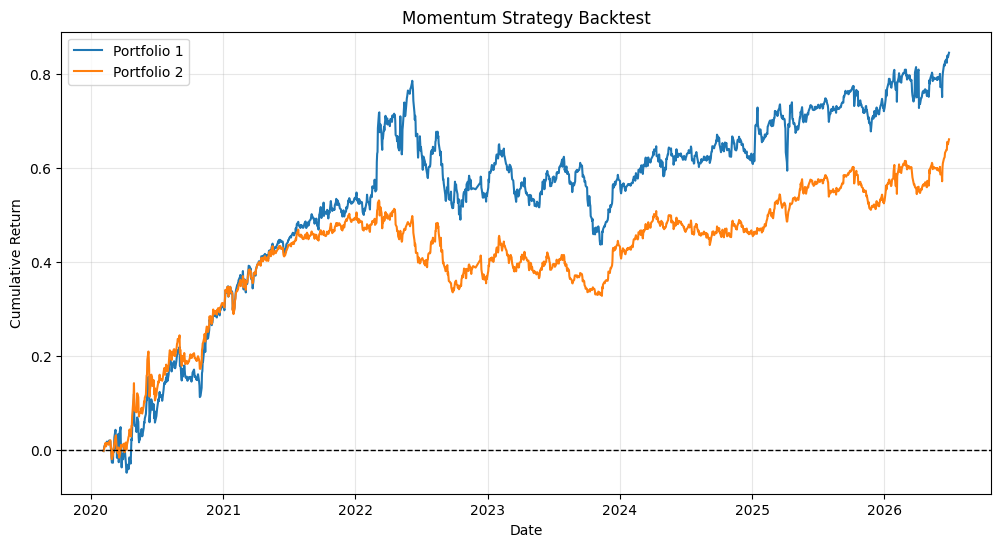

In [75]:
# Plot cumulative returns
plot_data = portfolio1[['ts_event', 'cumulative_return']].rename(columns={'cumulative_return': 'Portfolio 1'})
plot_data = plot_data.merge(portfolio2[['ts_event', 'cumulative_return']].rename(columns={'cumulative_return': 'Portfolio 2'}), on='ts_event', how='inner').dropna()

plt.figure(figsize=(12, 6))
plt.plot(plot_data['ts_event'], plot_data['Portfolio 1'], label='Portfolio 1')
plt.plot(plot_data['ts_event'], plot_data['Portfolio 2'], label='Portfolio 2')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Momentum Strategy Backtest')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Part 3 — Data Splitting and Momentum Analysis

## Objective

Split the data chronologically and evaluate the relationship between momentum-based signals and future returns through risk adjustment and portfolio grouping.

## Steps

1. Split the data into:
   - Train: January 1, 2020–June 1, 2024
   - Validation: June 1, 2024–June 1, 2025
   - Test: June 1, 2025–June 1, 2026 or later

2. Construct risk-adjusted momentum (`MOMRA`) and create scatter plots of:
   - MOM versus future return
   - MOMRA versus future return

3. Divide MOMRA into five fixed intervals:
   - \((-\infty,-1.5)\)
   - \([-1.5,-0.5)\)
   - \([-0.5,0.5)\)
   - \([0.5,1.5)\)
   - \([1.5,\infty)\)

4. Calculate the rolling percentile rank of MOM and divide it into five groups:
   - 0–20
   - 20–40
   - 40–60
   - 60–80
   - 80–100

5. Apply the same rolling-quantile grouping method to MOMRA.

6. Rank cross-sectional momentum (`CSMOM`) on each date and divide the assets into five groups.

7. For each group, calculate the average and standard deviation of future returns and present the results using bar plots.

In [76]:
# Prepare the Complete Historical Dataset
data_common['ts_event'] = pd.to_datetime(data_common['ts_event'])
data_common = data_common.sort_values(['ticker', 'ts_event']).reset_index(drop=True)
close_prices = data_common.pivot(index='ts_event', columns='ticker', values='close').sort_index()

In [77]:
# 2. Calculate MOM and MOMRA
FORWARD_DAYS = 5
SKIP_DAYS = 0

daily_returns = close_prices.pct_change(fill_method=None)
shifted_returns = daily_returns.shift(SKIP_DAYS)

mom = shifted_returns.rolling(window=MOM_WINDOW).mean()
rolling_volatility = shifted_returns.rolling(window=MOM_WINDOW).std()
momra = (mom / rolling_volatility) * np.sqrt(MOM_WINDOW)

# Future Return Rate
future_return_5d = close_prices.shift(-FORWARD_DAYS) / close_prices - 1

# Transform MOM and MOMRA into Long Format
mom_long = mom.rename_axis(index='ts_event', columns='ticker').stack().rename('MOM')
momra_long = momra.rename_axis(index='ts_event', columns='ticker').stack().rename('MOMRA')

# Build the Signal Table and Delay the Signal by One Calendar Day
signal_data = pd.concat([mom_long, momra_long], axis=1).dropna().reset_index()
signal_data['ts_event'] = signal_data['ts_event'] + timedelta(days=1)
signal_data = signal_data.sort_values(['ts_event', 'ticker']).reset_index(drop=True)

# Build the Future Return Table
return_data = future_return_5d.rename_axis(index='ts_event', columns='ticker').stack().rename('future_return_5d').reset_index()
return_data = return_data.sort_values(['ts_event', 'ticker']).reset_index(drop=True)

# Merge the Delayed Signal with Future Return
factor_data = pd.merge_asof(left=return_data, right=signal_data, on='ts_event', by='ticker', direction='backward')
factor_data = factor_data.dropna(subset=['MOM', 'MOMRA', 'future_return_5d']).sort_values(['ticker', 'ts_event']).reset_index(drop=True)

factor_data.head()

,ts_event,ticker,future_return_5d,MOM,MOMRA
0,2020-02-04 00:00:00+00:00,AGG,0.001930,0.000588,1.777084
1,2020-02-05 00:00:00+00:00,AGG,0.002196,0.000413,1.087011
2,2020-02-06 00:00:00+00:00,AGG,0.001933,0.000388,1.009312
3,2020-02-07 00:00:00+00:00,AGG,0.000613,0.000439,1.159887
4,2020-02-10 00:00:00+00:00,AGG,-0.000875,0.000678,1.753450


In [78]:
# 1. Split data into Train, Validation, and Test sets
# Training Set: 2020-01-01 - 2024-06-01
# Validation Set: 2024-06-01 - 2025-06-01
# Test Set: 2025-06-01 - 2026-06-01
train_factor = factor_data[(factor_data['ts_event'] >= '2020-01-01') & (factor_data['ts_event'] < '2024-06-01')].copy()
validation_factor = factor_data[(factor_data['ts_event'] >= '2024-06-01') & (factor_data['ts_event'] < '2025-06-01')].copy()
test_factor = factor_data[(factor_data['ts_event'] >= '2025-06-01') & (factor_data['ts_event'] <= '2026-06-01')].copy()

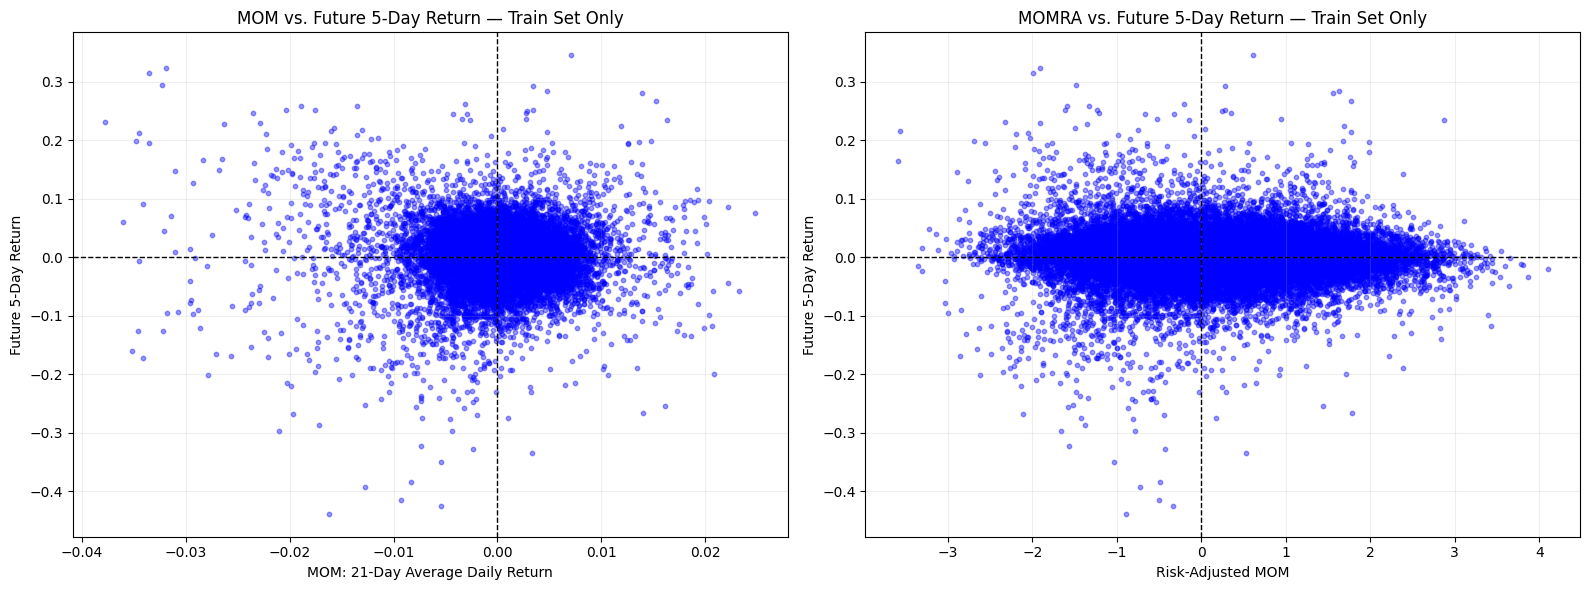

In [79]:
# 2. Scatterplot between MOM, MOMRA and Return
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(train_factor['MOM'], train_factor['future_return_5d'], alpha=0.4, s=10, color='blue')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('MOM vs. Future 5-Day Return — Train Set Only')
axes[0].set_xlabel('MOM: 21-Day Average Daily Return')
axes[0].set_ylabel('Future 5-Day Return')
axes[0].grid(alpha=0.2)

axes[1].scatter(train_factor['MOMRA'], train_factor['future_return_5d'], alpha=0.4, s=10, color='blue')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('MOMRA vs. Future 5-Day Return — Train Set Only')
axes[1].set_xlabel('Risk-Adjusted MOM')
axes[1].set_ylabel('Future 5-Day Return')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [80]:
# 3. MOMRA Groups Based On Intervals
momra_bins = [-np.inf, -1.5, -0.5, 0.5, 1.5, np.inf]
momra_labels = ['<-1.5', '-1.5 to -0.5', '-0.5 to 0.5', '0.5 to 1.5', '>=1.5']
factor_data['MOMRA_group'] = pd.cut(factor_data['MOMRA'], bins=momra_bins, labels=momra_labels, right=False, include_lowest=True)

train_factor = factor_data[(factor_data['ts_event'] >= '2020-01-01') & (factor_data['ts_event'] < '2024-06-01')].copy()
validation_factor = factor_data[(factor_data['ts_event'] >= '2024-06-01') & (factor_data['ts_event'] < '2025-06-01')].copy()
test_factor = factor_data[(factor_data['ts_event'] >= '2025-06-01') & (factor_data['ts_event'] <= '2026-06-01')].copy()

In [81]:
# 4. MOM Rolling Groups
ROLLING_QUANTILE_WINDOW = 252
quantile_bins = [0, 20, 40, 60, 80, 100]
quantile_labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
factor_data = factor_data.sort_values(['ticker', 'ts_event']).reset_index(drop=True)

factor_data['MOM_rolling_quantile'] = factor_data.groupby('ticker')['MOM'].transform(lambda series: series.rolling(window=ROLLING_QUANTILE_WINDOW).apply(lambda values: np.sum(values <= values[-1]) / len(values) * 100, raw=True))
factor_data['MOM_rolling_group'] = pd.cut(factor_data['MOM_rolling_quantile'], bins=quantile_bins, labels=quantile_labels, include_lowest=True)

In [82]:
# 5. MOMRA Rolling Groups
factor_data['MOMRA_rolling_quantile'] = factor_data.groupby('ticker')['MOMRA'].transform(lambda series: series.rolling(window=ROLLING_QUANTILE_WINDOW).apply(lambda values: np.sum(values <= values[-1]) / len(values) * 100, raw=True))
factor_data['MOMRA_rolling_group'] = pd.cut(factor_data['MOMRA_rolling_quantile'], bins=quantile_bins, labels=quantile_labels, include_lowest=True)

In [83]:
# 6. Cross-Sectional Momentum Rolling Groups
# Cross-Sectional Momentum compares an asset’s momentum with the momentum of other assets on the same date
factor_data['CSMOM_quantile'] = factor_data.groupby('ts_event')['MOM'].rank(method='first', pct=True) * 100

csmom_bins = [0, 20, 40, 60, 80, 100]
csmom_labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
factor_data['CSMOM_group'] = pd.cut(factor_data['CSMOM_quantile'], bins=csmom_bins, labels=csmom_labels, include_lowest=True)

In [84]:
# Update Three Sets After Arranging Groups on MOM, MOMRA, CSMOM
train_factor = factor_data[(factor_data['ts_event'] >= '2020-01-01') & (factor_data['ts_event'] < '2024-06-01')].copy()
validation_factor = factor_data[(factor_data['ts_event'] >= '2024-06-01') & (factor_data['ts_event'] < '2025-06-01')].copy()
test_factor = factor_data[(factor_data['ts_event'] >= '2025-06-01') & (factor_data['ts_event'] <= '2026-06-01')].copy()

In [85]:
# 7. Return Average and Standard Deviation & Bar Plot
def calculate_group_stats_and_plot(factor_dataset, group_column, plot_title):
    statistics = factor_dataset.groupby(group_column, observed=False)['future_return_5d'].agg(sample_size='count', average_return='mean', return_std='std').reset_index()
    plot_statistics = statistics.set_index(group_column)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plot_statistics['average_return'].plot(kind='bar', ax=axes[0], color='royalblue', width=0.75)
    axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0].set_title(f'{plot_title}: Average Future 5-Day Return — Train Only')
    axes[0].set_xlabel('Group')
    axes[0].set_ylabel('Average Future 5-Day Return')
    axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(axis='y', alpha=0.3)

    plot_statistics['return_std'].plot(kind='bar', ax=axes[1], color='darkorange', width=0.75)
    axes[1].set_title(f'{plot_title}: Future 5-Day Return Standard Deviation — Train Only')
    axes[1].set_xlabel('Group')
    axes[1].set_ylabel('Future 5-Day Return Standard Deviation')
    axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return statistics

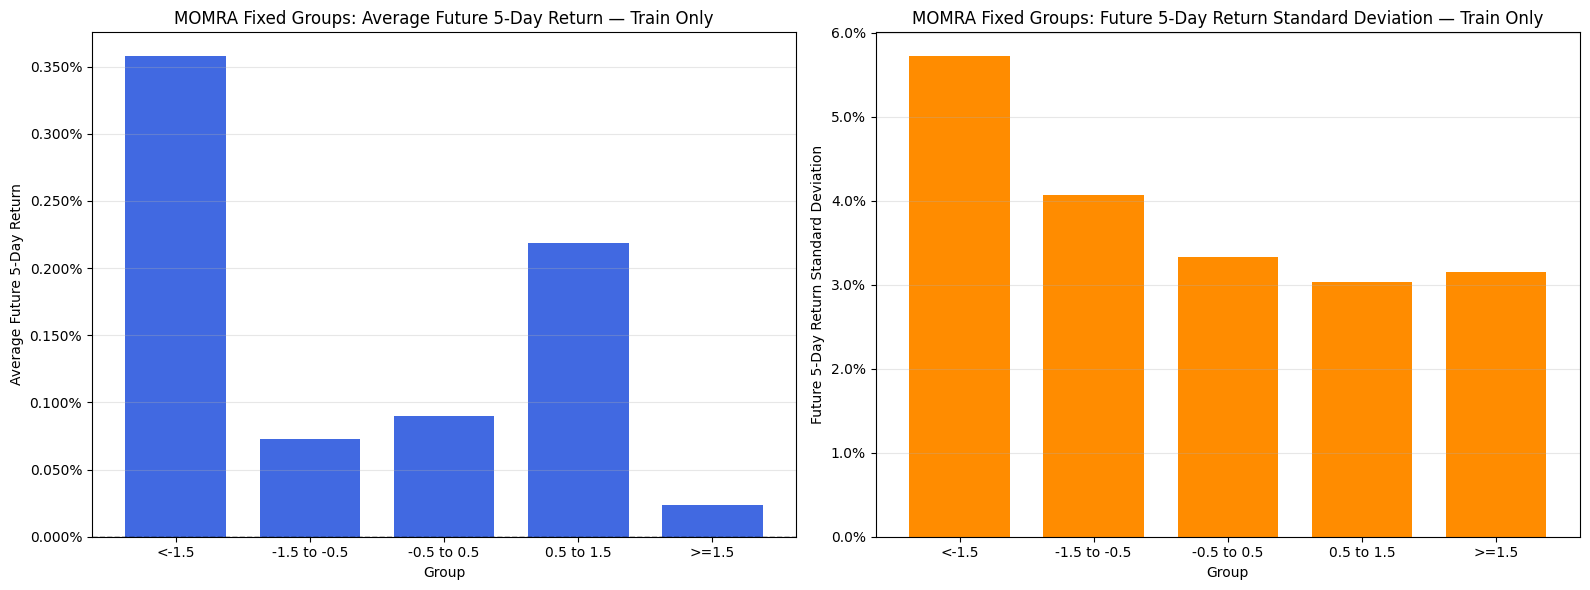

,MOMRA_group,sample_size,average_return,return_std
0,<-1.5,1630,0.003576,0.057211
1,-1.5 to -0.5,8825,0.000728,0.040693
2,-0.5 to 0.5,14787,0.000896,0.033358
3,0.5 to 1.5,11292,0.002187,0.030327
4,>=1.5,3315,0.000239,0.031508


In [86]:
momra_statistics = calculate_group_stats_and_plot(factor_dataset=train_factor,group_column='MOMRA_group', plot_title='MOMRA Fixed Groups')
momra_statistics

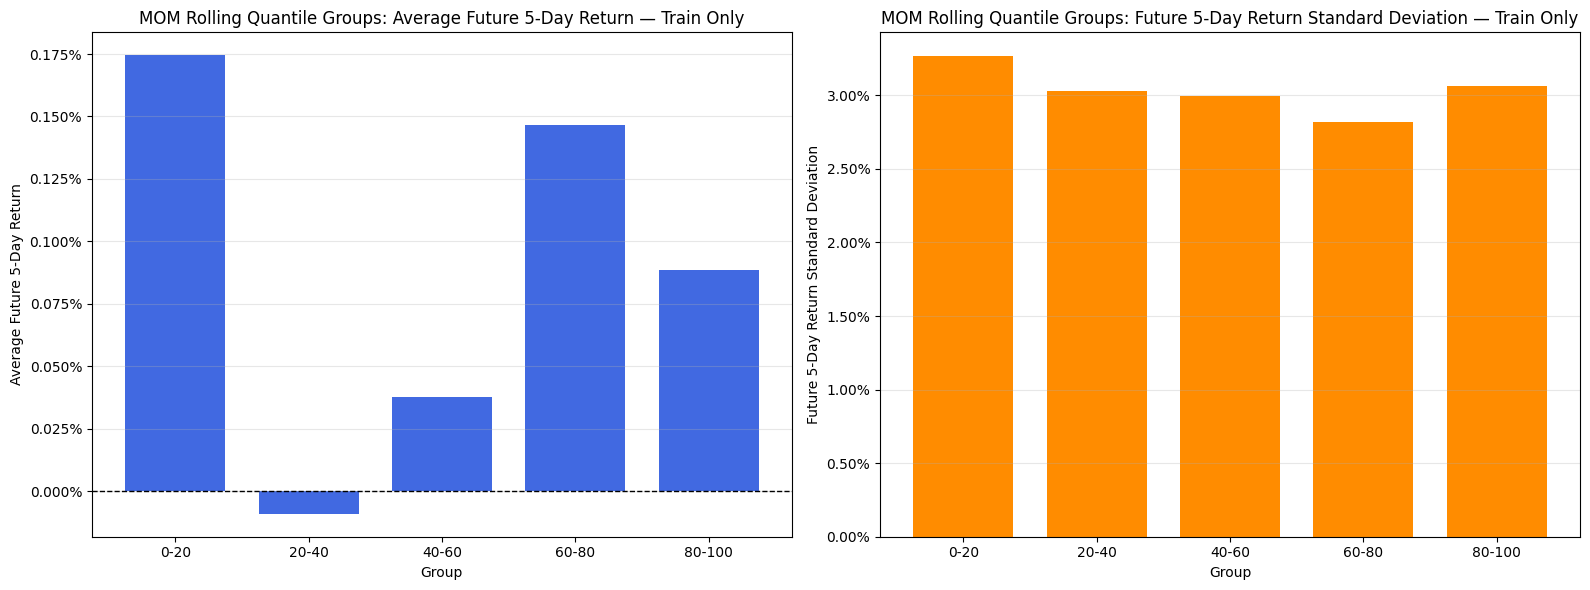

,MOM_rolling_group,sample_size,average_return,return_std
0,0-20,6959,0.001745,0.032651
1,20-40,5927,-0.000091,0.030268
2,40-60,6036,0.000375,0.029981
3,60-80,5773,0.001466,0.028159
4,80-100,5867,0.000886,0.030624


In [87]:
mom_rolling_statistics = calculate_group_stats_and_plot(factor_dataset=train_factor,group_column='MOM_rolling_group', plot_title='MOM Rolling Quantile Groups')
mom_rolling_statistics

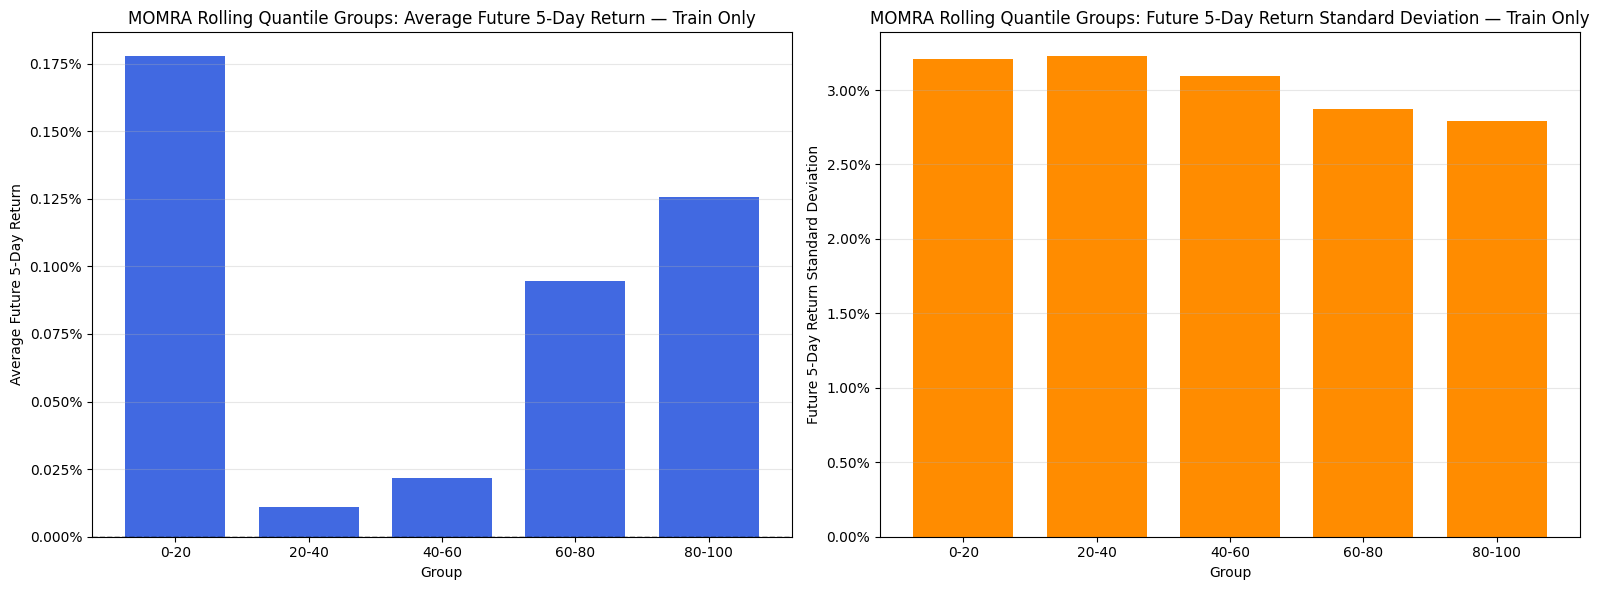

,MOMRA_rolling_group,sample_size,average_return,return_std
0,0-20,6869,0.001777,0.032094
1,20-40,5907,0.000110,0.032261
2,40-60,5702,0.000216,0.030920
3,60-80,5608,0.000945,0.028745
4,80-100,6476,0.001257,0.027922


In [88]:
momra_rolling_statistics = calculate_group_stats_and_plot(factor_dataset=train_factor,group_column='MOMRA_rolling_group', plot_title='MOMRA Rolling Quantile Groups')
momra_rolling_statistics

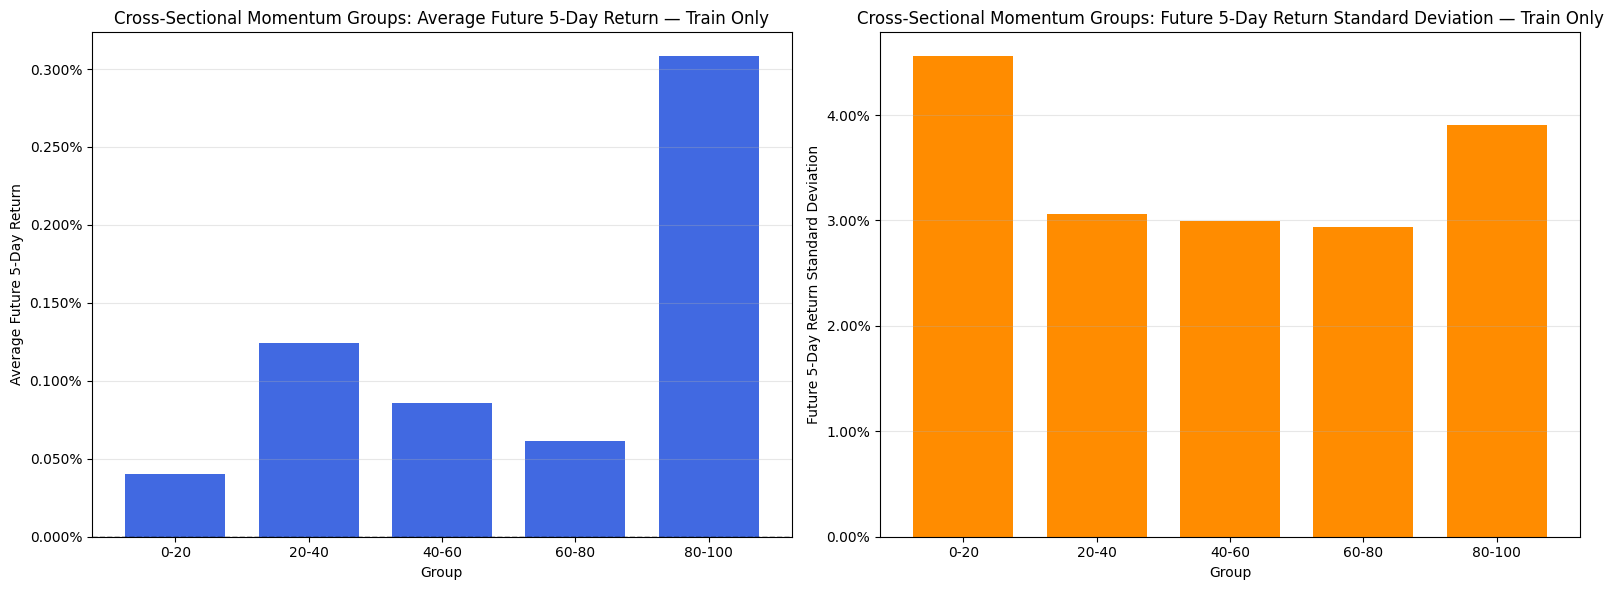

,CSMOM_group,sample_size,average_return,return_std
0,0-20,7539,0.000404,0.045565
1,20-40,7539,0.001242,0.030630
2,40-60,8616,0.000859,0.029948
3,60-80,7539,0.000614,0.029355
4,80-100,8616,0.003081,0.039016


In [89]:
csmom_statistics = calculate_group_stats_and_plot(factor_dataset=train_factor,group_column='CSMOM_group', plot_title='Cross-Sectional Momentum Groups')
csmom_statistics

# Part 4 — Signal-Based Portfolio Construction and MACD

## Objective

Convert signals into portfolio weights and evaluate long–short MACD strategies with different parameters and smoothing methods.

## Steps

1. Construct portfolio weights proportional to the signal values and use these weights to determine asset holdings.

2. Build long–short MACD portfolios and perform a grid search over different short- and long-term EMA windows. Summarize the results in a table and identify the best parameter combination(s).

3. Evaluate each MACD signal using the existing grouping bar plots and multi-asset backtester.

4. Apply an additional smoothing layer to the MACD signal and compare different smoothing parameters to select the best specification.

In [90]:
# Initial Parameters Setup

TARGET_GROSS_EXPOSURE = 2.0

TRAIN_START = '2020-01-01'
TRAIN_END = '2024-06-01'

VALIDATION_START = '2024-06-01'
VALIDATION_END = '2025-06-01'

In [91]:
# Find dates on which a signal can produce valid portfolio weights

def get_valid_signal_dates(signal_matrix):
    signal_matrix = signal_matrix.replace([np.inf, -np.inf], np.nan)
    demeaned_signal = signal_matrix.sub(signal_matrix.mean(axis=1), axis=0)
    absolute_signal_sum = demeaned_signal.abs().sum(axis=1)

    valid_mask = signal_matrix.notna().all(axis=1) & (absolute_signal_sum > 0)

    return signal_matrix.index[valid_mask]


# Convert any signal matrix into portfolio weights

def convert_signal_to_weights(signal_matrix, target_gross_exposure=2.0, rebalance_every=5, rebalance_dates=None):
    signal_matrix = signal_matrix.replace([np.inf, -np.inf], np.nan)

    # Cross-sectional demeaning
    demeaned_signal = signal_matrix.sub(signal_matrix.mean(axis=1), axis=0)
    absolute_signal_sum = demeaned_signal.abs().sum(axis=1)

    # Normalize signals into weights
    daily_weights = demeaned_signal.div(absolute_signal_sum, axis=0) * target_gross_exposure
    daily_weights = daily_weights.replace([np.inf, -np.inf], np.nan).dropna(how='any')

    # Use either the default dates or a fixed common calendar
    if rebalance_dates is None:
        rebalance_weights = daily_weights.iloc[::rebalance_every].copy()
    else:
        missing_dates = pd.Index(rebalance_dates).difference(daily_weights.index)

        if len(missing_dates) > 0:
            raise ValueError(f'{len(missing_dates)} rebalance dates do not have valid signal values.')

        rebalance_weights = daily_weights.loc[rebalance_dates].copy()

    rebalance_weights.index.name = 'ts_event'

    return rebalance_weights

In [92]:
# Calculate the average daily return using the NAV return rate

def calculate_average_return(portfolio_summary, start_date, end_date):
    return_data = portfolio_summary[['ts_event', 'cumulative_return']].dropna().copy()
    return_data['ts_event'] = pd.to_datetime(return_data['ts_event'], utc=True).dt.tz_localize(None)

    # Since NAV / initial capital = 1 + cumulative return
    return_data['daily_return'] = (1 + return_data['cumulative_return']).pct_change(fill_method=None)

    period_data = return_data[
        (return_data['ts_event'] >= pd.Timestamp(start_date)) &
        (return_data['ts_event'] < pd.Timestamp(end_date))
    ]

    return period_data['daily_return'].mean()

In [93]:
## Part 1: Use Original MOM and MOMRA Signals to Construct Portfolios

# Use dates that are valid for both MOM and MOMRA
part1_common_dates = get_valid_signal_dates(mom).intersection(
    get_valid_signal_dates(momra)
)

part1_common_dates = part1_common_dates.intersection(close_prices.index)
part1_rebalance_dates = part1_common_dates[::HOLDING_PERIOD]

mom_signal_weights = convert_signal_to_weights(
    signal_matrix=mom,
    target_gross_exposure=TARGET_GROSS_EXPOSURE,
    rebalance_dates=part1_rebalance_dates
)

momra_signal_weights = convert_signal_to_weights(
    signal_matrix=momra,
    target_gross_exposure=TARGET_GROSS_EXPOSURE,
    rebalance_dates=part1_rebalance_dates
)

In [94]:
# Run MOM and MOMRA signal-weighted portfolios

mom_signal_detail, mom_signal_portfolio = (multi_asset_backtester(data=data_common,weights=mom_signal_weights,capital=CAPITAL,delay=DELAY))
momra_signal_detail, momra_signal_portfolio = (multi_asset_backtester(data=data_common,weights=momra_signal_weights,capital=CAPITAL,delay=DELAY))

In [95]:
# Compare MOM and MOMRA using Train and Validation average daily returns

signal_portfolio_result = pd.DataFrame({
    'Portfolio': [
        'Weights Proportional to MOM',
        'Weights Proportional to MOMRA'
    ],
    'Train Average Daily Return': [
        calculate_average_return(mom_signal_portfolio, TRAIN_START, TRAIN_END),
        calculate_average_return(momra_signal_portfolio, TRAIN_START, TRAIN_END)
    ],
    'Validation Average Daily Return': [
        calculate_average_return(mom_signal_portfolio, VALIDATION_START, VALIDATION_END),
        calculate_average_return(momra_signal_portfolio, VALIDATION_START, VALIDATION_END)
    ]
})

display(signal_portfolio_result.style.format({
    'Train Average Daily Return': '{:.6%}',
    'Validation Average Daily Return': '{:.6%}'
}))

,Portfolio,Train Average Daily Return,Validation Average Daily Return
0,Weights Proportional to MOM,0.064863%,-0.014560%
1,Weights Proportional to MOMRA,0.052583%,-0.023824%


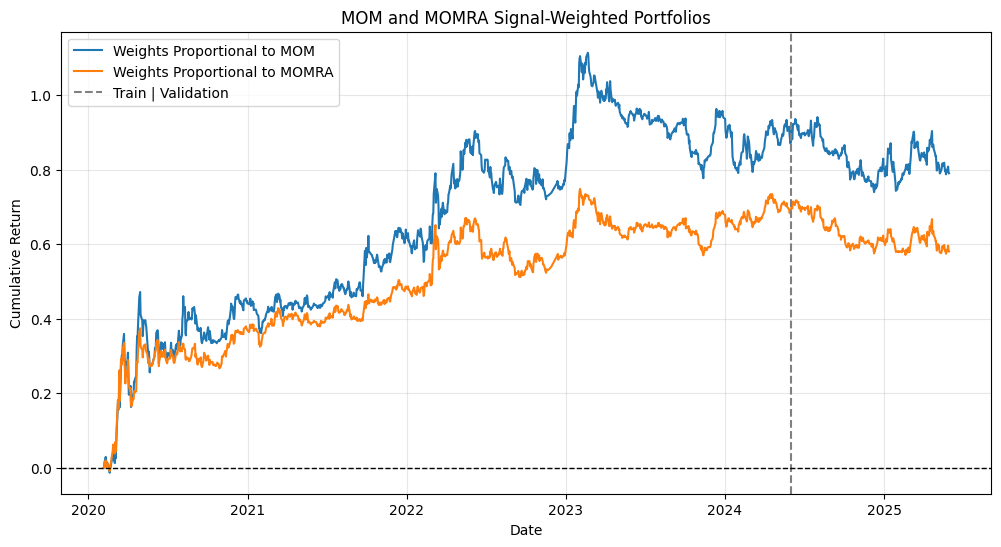

In [96]:
# Compare MOM and MOMRA portfolios

PLOT_START = pd.Timestamp(TRAIN_START)
PLOT_END = pd.Timestamp(VALIDATION_END)

def prepare_portfolio_curve(portfolio_summary, start_date, end_date):
    curve = portfolio_summary[['ts_event', 'cumulative_return']].dropna().copy()
    curve['ts_event'] = pd.to_datetime(curve['ts_event'], utc=True).dt.tz_localize(None)

    curve = curve[
        (curve['ts_event'] >= pd.Timestamp(start_date)) &
        (curve['ts_event'] < pd.Timestamp(end_date))
    ].copy()

    # Rebase cumulative return to the beginning of the selected period
    starting_value = 1 + curve['cumulative_return'].iloc[0]
    curve['cumulative_return'] = (1 + curve['cumulative_return']) / starting_value - 1

    return curve

# Prepare MOM portfolio curve
mom_curve = prepare_portfolio_curve(portfolio_summary=mom_signal_portfolio,start_date=PLOT_START,end_date=PLOT_END)

# Prepare MOMRA portfolio curve
momra_curve = prepare_portfolio_curve(portfolio_summary=momra_signal_portfolio,start_date=PLOT_START,end_date=PLOT_END)

# Plot MOM and MOMRA
plt.figure(figsize=(12, 6))
plt.plot(mom_curve['ts_event'],mom_curve['cumulative_return'],label='Weights Proportional to MOM')
plt.plot(momra_curve['ts_event'],momra_curve['cumulative_return'],label='Weights Proportional to MOMRA')

# Mark the boundary between Train and Validation
plt.axvline(pd.Timestamp(VALIDATION_START),color='gray',linestyle='--',linewidth=1.5,label='Train | Validation')
plt.axhline(0,color='black',linestyle='--',linewidth=1)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('MOM and MOMRA Signal-Weighted Portfolios')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [97]:
## Part 2: MACD Parameter Grid Search

# Set up MACD parameter windows
MOM_WINDOWS = {
    '1d': 1,
    '1w': 5,
    '2w': 10,
    '1m': 21,
    '1q': 63,
    '1y': 252
}

In [98]:
# Build all valid short-window and long-window combinations

parameter_combinations = []

for short_name, short_window in MOM_WINDOWS.items():
    for long_name, long_window in MOM_WINDOWS.items():

        if short_window < long_window:
            parameter_combinations.append({
                'short_name': short_name,
                'short_window': short_window,
                'long_name': long_name,
                'long_window': long_window
            })

parameter_table = pd.DataFrame(parameter_combinations)

parameter_table

,short_name,short_window,long_name,long_window
0,1d,1,1w,5
1,1d,1,2w,10
2,1d,1,1m,21
3,1d,1,1q,63
4,1d,1,1y,252
5,1w,5,2w,10
6,1w,5,1m,21
7,1w,5,1q,63
8,1w,5,1y,252
9,2w,10,1m,21


In [99]:
# Calculate the normalized MACD signal using short and long EMAs

def calculate_macd_signal(close_prices, short_window, long_window):

    # Calculate the short-term EMA
    short_ema = close_prices.ewm(span=short_window, adjust=False, min_periods=short_window).mean()

    # Calculate the long-term EMA
    long_ema = close_prices.ewm(span=long_window,adjust=False,min_periods=long_window).mean()

    # Calculate and normalize MACD across assets
    macd_signal = (short_ema - long_ema) / close_prices

    return macd_signal

In [100]:
# Run the MACD parameter grid search using one common calendar

macd_grid_results = []
macd_signal_dictionary = {}
macd_weights_dictionary = {}
macd_portfolio_dictionary = {}

# First calculate every MACD signal
for parameter in parameter_combinations:
    parameter_key = (
        parameter['short_window'],
        parameter['long_window']
    )

    macd_signal_dictionary[parameter_key] = calculate_macd_signal(
        close_prices=close_prices,
        short_window=parameter['short_window'],
        long_window=parameter['long_window']
    )


# Find dates valid for every MACD parameter combination
macd_common_dates = close_prices.index

for macd_signal in macd_signal_dictionary.values():
    macd_common_dates = macd_common_dates.intersection(
        get_valid_signal_dates(macd_signal)
    )

macd_rebalance_dates = macd_common_dates[::HOLDING_PERIOD]

print(f'Common MACD start date: {macd_rebalance_dates[0]}')
print(f'Number of common rebalance dates: {len(macd_rebalance_dates)}')


# Backtest every parameter using exactly the same dates
for parameter in parameter_combinations:
    short_name = parameter['short_name']
    short_window = parameter['short_window']
    long_name = parameter['long_name']
    long_window = parameter['long_window']
    parameter_key = (short_window, long_window)

    macd_signal = macd_signal_dictionary[parameter_key]

    macd_weights = convert_signal_to_weights(
        signal_matrix=macd_signal,
        target_gross_exposure=TARGET_GROSS_EXPOSURE,
        rebalance_dates=macd_rebalance_dates
    )

    _, macd_portfolio = multi_asset_backtester(
        data=data_common,
        weights=macd_weights,
        capital=CAPITAL,
        delay=DELAY
    )

    train_average_return = calculate_average_return(
        macd_portfolio,
        TRAIN_START,
        TRAIN_END
    )

    validation_average_return = calculate_average_return(
        macd_portfolio,
        VALIDATION_START,
        VALIDATION_END
    )

    macd_grid_results.append({
        'short_name': short_name,
        'short_window': short_window,
        'long_name': long_name,
        'long_window': long_window,
        'train_average_return': train_average_return,
        'validation_average_return': validation_average_return
    })

    macd_weights_dictionary[parameter_key] = macd_weights
    macd_portfolio_dictionary[parameter_key] = macd_portfolio

Common MACD start date: 2020-12-30 00:00:00+00:00
Number of common rebalance dates: 274


In [101]:
# Convert the grid-search results into a table

macd_grid_results = pd.DataFrame(macd_grid_results)

# Rank the parameters using the Train average return
macd_grid_results = macd_grid_results.sort_values(by='train_average_return', ascending=False).reset_index(drop=True)

display(macd_grid_results.style.format({'train_average_return': '{:.6%}', 'validation_average_return': '{:.6%}'}))

,short_name,short_window,long_name,long_window,train_average_return,validation_average_return
0,1d,1,1y,252,0.059699%,-0.036939%
1,1d,1,1q,63,0.059280%,-0.052939%
2,1w,5,1q,63,0.058792%,-0.063342%
3,2w,10,1q,63,0.058497%,-0.065405%
4,1w,5,1y,252,0.058335%,-0.032389%
5,2w,10,1y,252,0.056464%,-0.026279%
6,1m,21,1q,63,0.054984%,-0.070498%
7,2w,10,1m,21,0.052701%,-0.044054%
8,1m,21,1y,252,0.051416%,-0.021683%
9,1w,5,1m,21,0.046977%,-0.050913%


long_name,1d,1w,2w,1m,1q,1y
short_name,,,,,,
1d,NaN,0.0274,0.0274,0.0400,0.0593,0.0597
1w,NaN,NaN,0.0304,0.0470,0.0588,0.0583
2w,NaN,NaN,NaN,0.0527,0.0585,0.0565
1m,NaN,NaN,NaN,NaN,0.0550,0.0514
1q,NaN,NaN,NaN,NaN,NaN,0.0402
1y,NaN,NaN,NaN,NaN,NaN,NaN


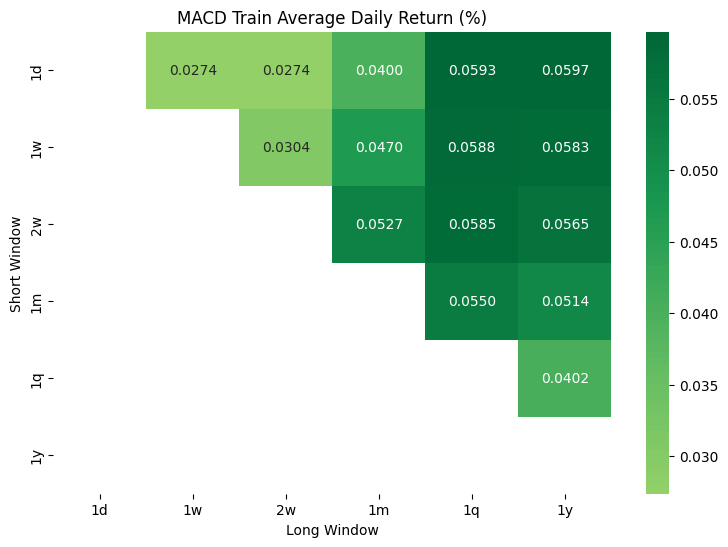

In [102]:
# Create the short-window versus long-window average-return table

window_order = ['1d', '1w', '2w', '1m', '1q', '1y']

train_average_return_table = macd_grid_results.pivot(index='short_name', columns='long_name', values='train_average_return').reindex(index=window_order, columns=window_order)

display((train_average_return_table * 100).round(4))

plt.figure(figsize=(9, 6))
sns.heatmap(train_average_return_table * 100, annot=True, fmt='.4f', cmap='RdYlGn', center=0)
plt.title('MACD Train Average Daily Return (%)')
plt.xlabel('Long Window')
plt.ylabel('Short Window')
plt.show()

In [103]:
## Part 3: Put MACD Signal Into Barplot

def build_macd_factor_data(macd_signal,close_prices,forward_days=5):

    # Delay the MACD signal by one trading day
    delayed_macd_signal = macd_signal.shift(1)

    # Calculate the future return beginning on the execution date
    future_return = (close_prices.shift(-forward_days) / close_prices - 1)

    # Convert the wide MACD table into long format
    macd_long = (delayed_macd_signal.rename_axis(index='ts_event',columns='ticker').stack().rename('MACD'))

    # Convert the wide future-return table into long format
    future_return_long = (future_return.rename_axis(index='ts_event',columns='ticker').stack().rename('future_return_5d'))

    # Combine MACD signal and future return
    macd_factor_data = (pd.concat([macd_long,future_return_long],axis=1).dropna().reset_index())

    return macd_factor_data

In [104]:
# Divide MACD signals into five cross-sectional groups

def create_macd_groups(macd_factor_data):
    macd_factor_data = macd_factor_data.copy()

    # Rank assets by MACD on each date
    macd_factor_data['MACD_percentile'] = (macd_factor_data.groupby('ts_event')['MACD'].rank(method='first',pct=True) * 100)

    # Define five signal groups
    macd_bins = [
        0,
        20,
        40,
        60,
        80,
        100
    ]
    macd_labels = [
        '0-20',
        '20-40',
        '40-60',
        '60-80',
        '80-100'
    ]
    macd_factor_data['MACD_group'] = pd.cut(macd_factor_data['MACD_percentile'],bins=macd_bins,labels=macd_labels,include_lowest=True)

    return macd_factor_data

# Bar Plot: Mean Return Only

def calculate_mean_group_return_and_plot(factor_dataset, group_column, plot_title):
    statistics = (
        factor_dataset
        .groupby(group_column, observed=False)['future_return_5d']
        .agg(sample_size='count', average_return='mean')
        .reset_index()
    )

    plt.figure(figsize=(9, 5))
    plt.bar(
        statistics[group_column].astype(str),
        statistics['average_return'],
        color='royalblue',
        width=0.75
    )

    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.title(f'{plot_title}: Average Future 5-Day Return — Train Only')
    plt.xlabel('MACD Group')
    plt.ylabel('Average Future 5-Day Return')
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    return statistics

Best MACD combination: Short = 1, Long = 252


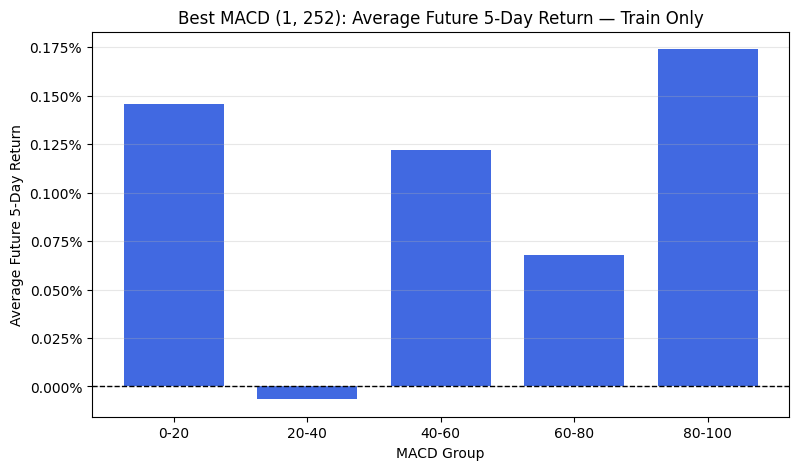

,MACD_group,sample_size,average_return
0,0-20,5929,0.001456
1,20-40,5929,-0.000066
2,40-60,6776,0.001220
3,60-80,5929,0.000679
4,80-100,6776,0.001739


In [105]:
# Plot the Best MACD Parameter Combination Only

# 1. Get the best parameter combination
best_parameter = macd_grid_results.iloc[0]
best_short_window = int(best_parameter['short_window'])
best_long_window = int(best_parameter['long_window'])
best_parameter_key = (best_short_window,best_long_window)

print(
    f'Best MACD combination: '
    f'Short = {best_short_window}, '
    f'Long = {best_long_window}'
)

# 2. Retrieve the MACD signal
best_macd_signal = macd_signal_dictionary[best_parameter_key]

# 3. Align the best MACD signal with future return
best_macd_factor_data = build_macd_factor_data(macd_signal=best_macd_signal,close_prices=close_prices,forward_days=FORWARD_DAYS)

# 4. Divide the MACD signal into five groups
best_macd_factor_data = create_macd_groups(best_macd_factor_data)

# 5. Convert dates into timezone-naive dates for comparison
comparison_dates = (pd.to_datetime(best_macd_factor_data['ts_event'],utc=True).dt.tz_localize(None))
train_start_date = pd.Timestamp(TRAIN_START)
train_end_date = pd.Timestamp(TRAIN_END)

# 6. Keep Train data only
best_train_macd_factor = best_macd_factor_data[(comparison_dates >= train_start_date) & (comparison_dates < train_end_date)].copy()

# 7. Use the existing bar-plot function
best_macd_statistics = calculate_mean_group_return_and_plot(factor_dataset=best_train_macd_factor,group_column='MACD_group',
plot_title=(
        f'Best MACD '
        f'({best_short_window}, {best_long_window})'
    ))

best_macd_statistics

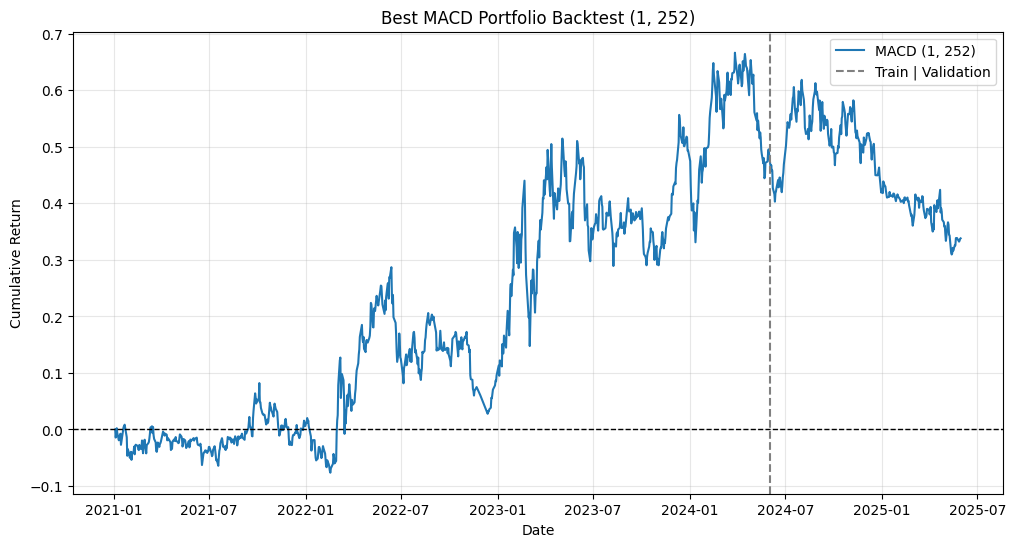

In [106]:
# Plot the Train and Validation backtest of the best MACD combination

best_macd_portfolio = macd_portfolio_dictionary[best_parameter_key]

best_macd_plot_data = prepare_portfolio_curve(
    portfolio_summary=best_macd_portfolio,
    start_date=TRAIN_START,
    end_date=VALIDATION_END
)

plt.figure(figsize=(12, 6))

plt.plot(
    best_macd_plot_data['ts_event'],
    best_macd_plot_data['cumulative_return'],
    label=f'MACD ({best_short_window}, {best_long_window})'
)

plt.axvline(
    pd.Timestamp(VALIDATION_START),
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='Train | Validation'
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title(f'Best MACD Portfolio Backtest ({best_short_window}, {best_long_window})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [107]:
## Part 4: Apply EWMA smoother to the best MACD signal

BEST_SHORT_WINDOW = best_short_window
BEST_LONG_WINDOW = best_long_window
SMOOTH_SPANS = [3, 5, 7, 9, 12, 21]

raw_macd_signal = macd_signal_dictionary[
    (BEST_SHORT_WINDOW, BEST_LONG_WINDOW)
]

smoother_results_list = []
smoothed_signal_dictionary = {}
smoothed_weights_dictionary = {}
smoothed_portfolio_dictionary = {}

# First calculate every smoothed signal
for smooth_span in SMOOTH_SPANS:
    smoothed_signal_dictionary[smooth_span] = raw_macd_signal.ewm(
        span=smooth_span,
        adjust=False,
        min_periods=smooth_span
    ).mean()


# Find dates valid for every smoother
smoother_common_dates = get_valid_signal_dates(raw_macd_signal)

for smoothed_signal in smoothed_signal_dictionary.values():
    smoother_common_dates = smoother_common_dates.intersection(
        get_valid_signal_dates(smoothed_signal)
    )

smoother_rebalance_dates = smoother_common_dates[::HOLDING_PERIOD]


# Re-run raw MACD on the same smoother calendar
raw_comparison_weights = convert_signal_to_weights(
    signal_matrix=raw_macd_signal,
    target_gross_exposure=TARGET_GROSS_EXPOSURE,
    rebalance_dates=smoother_rebalance_dates
)

_, raw_comparison_portfolio = multi_asset_backtester(
    data=data_common,
    weights=raw_comparison_weights,
    capital=CAPITAL,
    delay=DELAY
)


# Backtest every smoother on the same dates
for smooth_span in SMOOTH_SPANS:
    smoothed_signal = smoothed_signal_dictionary[smooth_span]

    smoothed_weights = convert_signal_to_weights(
        signal_matrix=smoothed_signal,
        target_gross_exposure=TARGET_GROSS_EXPOSURE,
        rebalance_dates=smoother_rebalance_dates
    )

    _, smoothed_portfolio = multi_asset_backtester(
        data=data_common,
        weights=smoothed_weights,
        capital=CAPITAL,
        delay=DELAY
    )

    train_average_return = calculate_average_return(
        smoothed_portfolio,
        TRAIN_START,
        TRAIN_END
    )

    validation_average_return = calculate_average_return(
        smoothed_portfolio,
        VALIDATION_START,
        VALIDATION_END
    )

    smoother_results_list.append({
        'short_window': BEST_SHORT_WINDOW,
        'long_window': BEST_LONG_WINDOW,
        'smooth_span': smooth_span,
        'train_average_return': train_average_return,
        'validation_average_return': validation_average_return
    })

    smoothed_weights_dictionary[smooth_span] = smoothed_weights
    smoothed_portfolio_dictionary[smooth_span] = smoothed_portfolio

In [108]:
# Calculate raw MACD performance on the same smoother calendar

raw_train_average_return = calculate_average_return(raw_comparison_portfolio,TRAIN_START,TRAIN_END)
raw_validation_average_return = calculate_average_return(raw_comparison_portfolio,VALIDATION_START,VALIDATION_END)

# Convert the smoother results into a table

smoother_grid_results = pd.DataFrame(smoother_results_list)

smoother_grid_results = smoother_grid_results.sort_values(
    by='train_average_return',
    ascending=False
).reset_index(drop=True)

raw_comparison_result = pd.DataFrame({
    'short_window': [BEST_SHORT_WINDOW],
    'long_window': [BEST_LONG_WINDOW],
    'smooth_span': ['Raw MACD'],
    'train_average_return': [raw_train_average_return],
    'validation_average_return': [raw_validation_average_return]
})

smoother_comparison_table = pd.concat(
    [raw_comparison_result, smoother_grid_results],
    ignore_index=True
)

display(smoother_comparison_table.style.format({
    'train_average_return': '{:.6%}',
    'validation_average_return': '{:.6%}'
}))

# Select the best smoother among the smoothed versions
best_smooth_span = int(smoother_grid_results.loc[0, 'smooth_span'])
best_smoothed_signal = smoothed_signal_dictionary[best_smooth_span]
best_smoothed_weights = smoothed_weights_dictionary[best_smooth_span]
best_smoothed_portfolio = smoothed_portfolio_dictionary[best_smooth_span]

print(f'Best smoother span: {best_smooth_span}')
print(f'Raw Train return: {raw_train_average_return:.6%}')
print(f'Best smoother Train return: {smoother_grid_results.loc[0, "train_average_return"]:.6%}')
print(f'Raw Validation return: {raw_validation_average_return:.6%}')
print(f'Best smoother Validation return: {smoother_grid_results.loc[0, "validation_average_return"]:.6%}')

,short_window,long_window,smooth_span,train_average_return,validation_average_return
0,1,252,Raw MACD,0.063017%,-0.035854%
1,1,252,3,0.061783%,-0.035805%
2,1,252,5,0.060917%,-0.033259%
3,1,252,7,0.060114%,-0.030818%
4,1,252,9,0.059195%,-0.028701%
5,1,252,12,0.057699%,-0.026613%
6,1,252,21,0.053392%,-0.023912%


Best smoother span: 3
Raw Train return: 0.063017%
Best smoother Train return: 0.061783%
Raw Validation return: -0.035854%
Best smoother Validation return: -0.035805%


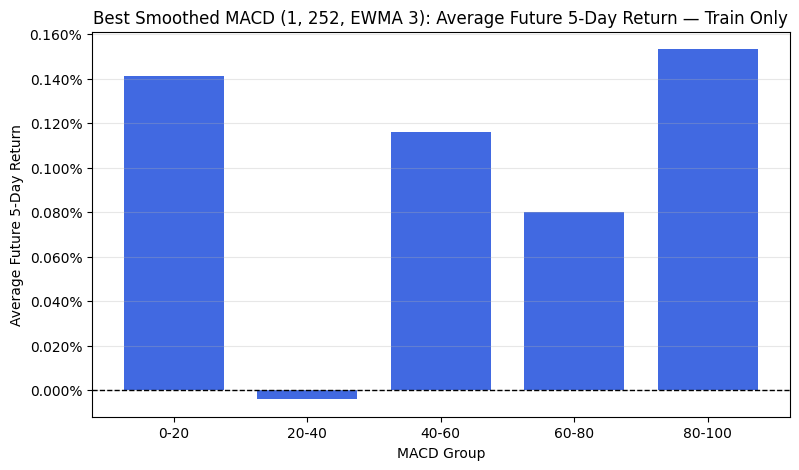

,MACD_group,sample_size,average_return
0,0-20,5915,0.001412
1,20-40,5915,-0.000041
2,40-60,6760,0.001161
3,60-80,5915,0.000799
4,80-100,6760,0.001532


In [109]:
# Build factor data for the best smoothed signal

best_smoothed_factor_data = build_macd_factor_data(macd_signal=best_smoothed_signal,close_prices=close_prices,forward_days=FORWARD_DAYS)

# Add the five MACD groups
best_smoothed_factor_data = create_macd_groups(best_smoothed_factor_data)

# Standardize dates for comparison
comparison_dates = (pd.to_datetime(best_smoothed_factor_data['ts_event'],utc=True).dt.tz_localize(None))

# Keep Train data only
best_smoothed_train_factor = (best_smoothed_factor_data[(comparison_dates >= pd.Timestamp(TRAIN_START)) & (comparison_dates < pd.Timestamp(TRAIN_END))].copy())

# Use the existing bar-plot function
best_smoothed_statistics = calculate_mean_group_return_and_plot(
    factor_dataset=best_smoothed_train_factor,
    group_column='MACD_group',
    plot_title=f'Best Smoothed MACD ({BEST_SHORT_WINDOW}, {BEST_LONG_WINDOW}, EWMA {best_smooth_span})'
)

best_smoothed_statistics

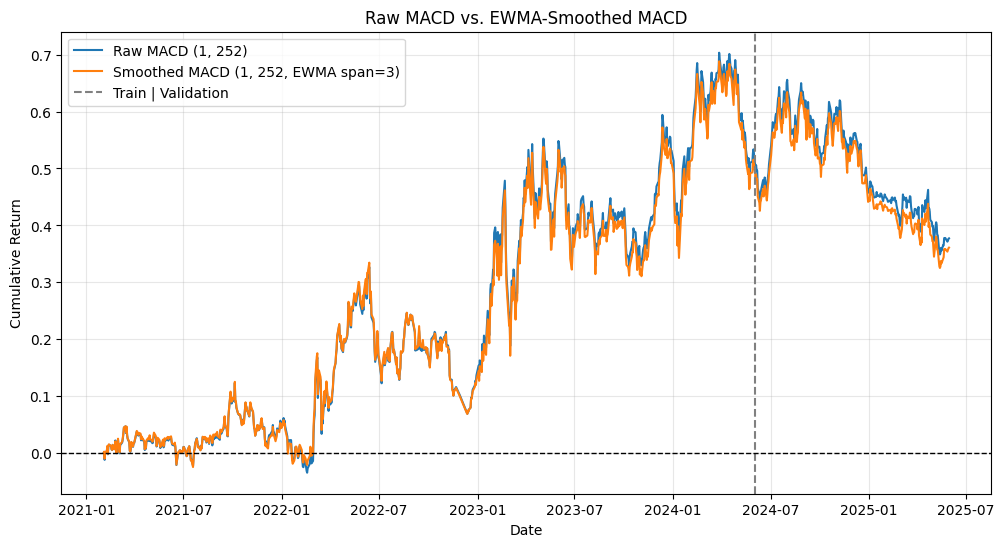

In [110]:
# Compare raw MACD with the best EWMA-smoothed MACD on the same calendar

raw_curve = prepare_portfolio_curve(
    portfolio_summary=raw_comparison_portfolio,
    start_date=TRAIN_START,
    end_date=VALIDATION_END
).rename(columns={'cumulative_return': 'raw_cumulative_return'})

smoothed_curve = prepare_portfolio_curve(
    portfolio_summary=best_smoothed_portfolio,
    start_date=TRAIN_START,
    end_date=VALIDATION_END
).rename(columns={'cumulative_return': 'smoothed_cumulative_return'})

comparison_curve = raw_curve.merge(
    smoothed_curve,
    on='ts_event',
    how='inner'
)

plt.figure(figsize=(12, 6))

plt.plot(
    comparison_curve['ts_event'],
    comparison_curve['raw_cumulative_return'],
    label=f'Raw MACD ({BEST_SHORT_WINDOW}, {BEST_LONG_WINDOW})'
)

plt.plot(
    comparison_curve['ts_event'],
    comparison_curve['smoothed_cumulative_return'],
    label=f'Smoothed MACD ({BEST_SHORT_WINDOW}, {BEST_LONG_WINDOW}, EWMA span={best_smooth_span})'
)

plt.axvline(
    pd.Timestamp(VALIDATION_START),
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='Train | Validation'
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Raw MACD vs. EWMA-Smoothed MACD')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Part 5 — Market Regimes and Residual Signal Analysis

## Objective

Evaluate portfolio performance under different VIX and MOVE regimes and test whether residualized momentum exposure contains information about future returns.

## Steps

1. Group VIX and MOVE using two methods:
   - Fixed groups based on `ceiling(log(index²))`
   - Rolling quantile groups

2. Compare the existing portfolio’s performance across the different VIX and MOVE regimes.

3. Create a two-dimensional table showing portfolio performance for each combination of VIX and MOVE groups.

4. Estimate VIX beta and MOM beta, then regress MOM beta on VIX beta.

5. Extract the regression residuals and test whether they provide an indication of future returns.

6. Complete the existing signal analysis and prepare the final signal set for the modeling stage.

In [111]:
vix_data = pd.read_csv('/content/VIX_index_1d_2020_now.csv')
move_data = pd.read_csv('/content/MOVE_index_1d_2020_now.csv')

display(vix_data.head())
display(move_data.head())

,Date,Open,High,Low,Close
0,2020/1/2,13.46,13.720000,12.42,12.47
1,2020/1/3,15.01,16.200001,13.13,14.02
2,2020/1/6,15.45,16.389999,13.54,13.85
3,2020/1/7,13.84,14.460000,13.39,13.79
4,2020/1/8,15.16,15.240000,12.83,13.45


,Date,Open,High,Low,Close
0,2020/1/2,57.200001,57.200001,57.200001,57.200001
1,2020/1/3,60.119999,60.119999,60.119999,60.119999
2,2020/1/6,62.790001,62.790001,62.790001,62.790001
3,2020/1/7,62.630001,62.630001,62.630001,62.630001
4,2020/1/8,60.490002,60.490002,60.490002,60.490002


In [112]:
## Clean and merge VIX and MOVE data

vix = vix_data[["Date", "Close"]].rename(columns={"Date": "ts_event", "Close": "VIX"})
move = move_data[["Date", "Close"]].rename(columns={"Date": "ts_event", "Close": "MOVE"})

# Convert the date columns to datetime format
vix["ts_event"] = pd.to_datetime(vix["ts_event"])
move["ts_event"] = pd.to_datetime(move["ts_event"])

# Merge VIX and MOVE using their common trading dates
index_data = vix.merge(move, on="ts_event", how="inner")
index_data = index_data.dropna().sort_values("ts_event").reset_index(drop=True)

display(index_data.head())

,ts_event,VIX,MOVE
0,2020-01-02,12.47,57.200001
1,2020-01-03,14.02,60.119999
2,2020-01-06,13.85,62.790001
3,2020-01-07,13.79,62.630001
4,2020-01-08,13.45,60.490002


**Measurement 1**

In [113]:
## Create fixed log regimes

index_data['VIX_log_group'] = np.ceil(np.log(index_data['VIX'] ** 2)).astype(int)
index_data['MOVE_log_group'] = np.ceil(np.log(index_data['MOVE'] ** 2)).astype(int)

display(index_data[
        [
            'ts_event',
            'VIX',
            'VIX_log_group',
            'MOVE',
            'MOVE_log_group'
        ]].head()
)

,ts_event,VIX,VIX_log_group,MOVE,MOVE_log_group
0,2020-01-02,12.47,6,57.200001,9
1,2020-01-03,14.02,6,60.119999,9
2,2020-01-06,13.85,6,62.790001,9
3,2020-01-07,13.79,6,62.630001,9
4,2020-01-08,13.45,6,60.490002,9


In [114]:
## Create rolling-quantile regimes

ROLLING_REGIME_WINDOW = 252
VOLATILITY_QUANTILE_LABELS = ['Q1','Q2','Q3','Q4','Q5']
QUANTILE_BINS = [0,0.2,0.4,0.6,0.8,1.0]

def calculate_rolling_percentile(series, window=252):
    return series.rolling(window=window,min_periods=window).apply(
        lambda values: np.mean(values <= values[-1]),
        raw=True)

index_data['VIX_rolling_pct'] = calculate_rolling_percentile(index_data['VIX'],ROLLING_REGIME_WINDOW)
index_data['MOVE_rolling_pct'] = calculate_rolling_percentile(index_data['MOVE'],ROLLING_REGIME_WINDOW)
index_data['VIX_quantile_group'] = pd.cut(index_data['VIX_rolling_pct'],bins=QUANTILE_BINS,labels=VOLATILITY_QUANTILE_LABELS,include_lowest=True)
index_data['MOVE_quantile_group'] = pd.cut(index_data['MOVE_rolling_pct'],bins=QUANTILE_BINS,labels=VOLATILITY_QUANTILE_LABELS,include_lowest=True)

display(index_data.dropna().head())

,ts_event,VIX,MOVE,VIX_log_group,MOVE_log_group,VIX_rolling_pct,MOVE_rolling_pct,VIX_quantile_group,MOVE_quantile_group
251,2021-01-04,26.969999,49.590000,7,8,0.515873,0.396825,Q3,Q2
252,2021-01-05,25.340000,48.950001,7,8,0.396825,0.369048,Q2,Q2
253,2021-01-06,25.070000,44.639999,7,8,0.388889,0.234127,Q2,Q2
254,2021-01-07,22.370001,45.200001,7,8,0.226190,0.253968,Q2,Q2
255,2021-01-08,21.559999,44.810001,7,8,0.174603,0.238095,Q1,Q2


In [115]:
## Build MOM quintiles using non-bond assets and Train data

MOM_QUINTILE_LABELS = ['Q1','Q2','Q3','Q4','Q5']
EXCLUDED_TICKERS = ['AGG','TLT','HYG','IEF','SHY','VIX','^VIX']

conditional_factor = factor_data[['ts_event','ticker','MOM','future_return_5d']].dropna().copy()
conditional_factor['ts_event'] = pd.to_datetime(conditional_factor['ts_event'],utc=True).dt.tz_localize(None)

# Exclude bond ETFs and the VIX index
conditional_factor = conditional_factor[~conditional_factor['ticker'].astype(str).str.upper().isin(EXCLUDED_TICKERS)].copy()

# Keep Train data only
conditional_factor = conditional_factor[(conditional_factor['ts_event'] >= pd.Timestamp(TRAIN_START)) &
    (conditional_factor['ts_event'] < pd.Timestamp(TRAIN_END))].copy()

# Prevent the future five-day return from entering Validation
train_trading_dates = pd.DatetimeIndex(pd.to_datetime(close_prices.index, utc=True)).tz_localize(None)
train_trading_dates = train_trading_dates[(train_trading_dates >= pd.Timestamp(TRAIN_START)) &
    (train_trading_dates < pd.Timestamp(TRAIN_END))]
last_valid_train_signal_date = train_trading_dates[ -(FORWARD_DAYS + 1)]
conditional_factor = conditional_factor[conditional_factor['ts_event'] <= last_valid_train_signal_date].copy()

# Rank MOM cross-sectionally on every date
conditional_factor['MOM_percentile'] = (conditional_factor.groupby('ts_event')['MOM'].rank(method='first', pct=True))

# Divide MOM into five quintiles
conditional_factor['MOM_quintile'] = pd.cut(conditional_factor['MOM_percentile'],bins=QUANTILE_BINS,labels=MOM_QUINTILE_LABELS,include_lowest=True)

display(conditional_factor.head())

,ts_event,ticker,MOM,future_return_5d,MOM_percentile,MOM_quintile
1591,2020-02-04,DBA,-0.002566,0.010863,0.21875,Q2
1592,2020-02-05,DBA,-0.001926,0.002554,0.18750,Q1
1593,2020-02-06,DBA,-0.002012,0.008878,0.18750,Q1
1594,2020-02-07,DBA,-0.001794,0.006313,0.25000,Q2
1595,2020-02-10,DBA,-0.001350,0.016435,0.21875,Q2


In [116]:
## Merge MOM quintiles with VIX and MOVE regimes

regime_columns = ['ts_event','VIX','MOVE','VIX_log_group','MOVE_log_group','VIX_quantile_group','MOVE_quantile_group']
conditional_data = conditional_factor.merge(index_data[regime_columns],on='ts_event',how='inner')

# Use one common sample for all four tables
conditional_data = conditional_data.dropna(subset=['MOM','MOM_quintile','future_return_5d','VIX_log_group','MOVE_log_group','VIX_quantile_group','MOVE_quantile_group']).copy()

display(conditional_data.head())

,ts_event,ticker,MOM,future_return_5d,MOM_percentile,MOM_quintile,VIX,MOVE,VIX_log_group,MOVE_log_group,VIX_quantile_group,MOVE_quantile_group
229,2021-01-04,DBA,0.002344,-0.005587,0.87500,Q5,26.969999,49.590000,7,8,Q3,Q2
230,2021-01-05,DBA,0.002165,0.007407,0.78125,Q4,25.340000,48.950001,7,8,Q2,Q2
231,2021-01-06,DBA,0.002184,0.014268,0.75000,Q4,25.070000,44.639999,7,8,Q2,Q2
232,2021-01-07,DBA,0.002502,0.024845,0.71875,Q4,22.370001,45.200001,7,8,Q2,Q2
233,2021-01-08,DBA,0.002163,0.041693,0.56250,Q3,21.559999,44.810001,7,8,Q1,Q2


In [117]:
## Create conditional MOM tables and heatmaps

MINIMUM_OBSERVATIONS = 20

def create_conditional_mom_heatmap(dataset,regime_column,plot_title):
    # Calculate mean future five-day return
    mean_return_table = dataset.pivot_table(index=regime_column,columns='MOM_quintile',values='future_return_5d',aggfunc='mean',observed=False).reindex(columns=MOM_QUINTILE_LABELS)

    # Calculate sample size
    count_table = dataset.pivot_table(index=regime_column,columns='MOM_quintile',values='future_return_5d',aggfunc='count',observed=False).reindex(columns=MOM_QUINTILE_LABELS)

    # Convert returns into basis points
    mean_return_bp = mean_return_table * 10000

    # Put return and sample size in each heatmap cell
    annotations = pd.DataFrame('',index=mean_return_bp.index,columns=mean_return_bp.columns)

    for row in mean_return_bp.index:
        for column in mean_return_bp.columns:
            mean_value = mean_return_bp.loc[row, column]
            sample_size = count_table.loc[row, column]

            if pd.notna(mean_value) and sample_size > 0:
                low_sample_mark = (
                    '*'
                    if sample_size < MINIMUM_OBSERVATIONS
                    else ''
                )

                annotations.loc[row, column] = (
                    f'{mean_value:.1f}{low_sample_mark}\n'
                    f'n={int(sample_size)}'
                )

    # Determine the color scale using reliable cells
    reliable_values = mean_return_bp.where(count_table >= MINIMUM_OBSERVATIONS).stack()

    if len(reliable_values) > 0:
        color_limit = reliable_values.abs().max()
    else:
        color_limit = mean_return_bp.stack().abs().max()

    if pd.isna(color_limit) or color_limit == 0:
        color_limit = 1

    # Plot heatmap
    plt.figure(figsize=(12, 6))

    sns.heatmap(
        mean_return_bp,
        annot=annotations,
        fmt='',
        cmap='RdYlGn',
        center=0,
        vmin=-color_limit,
        vmax=color_limit,
        linewidths=0.5,
        linecolor='white'
    )
    plt.title(f'{plot_title}\n'f'Mean Future 5-Day Return (bp)')
    plt.xlabel('MOM Quintile')
    plt.ylabel('Volatility Regime')
    plt.show()

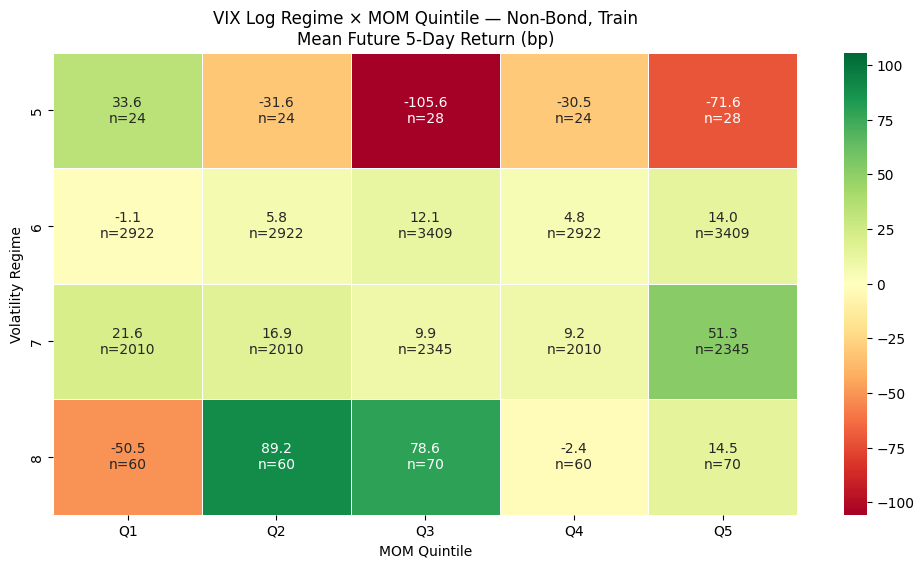

In [118]:
## VIX Log Regime × MOM Quintile

vix_log_results = create_conditional_mom_heatmap(
    dataset=conditional_data,
    regime_column='VIX_log_group',
    plot_title=(
        'VIX Log Regime × MOM Quintile '
        '— Non-Bond, Train'))

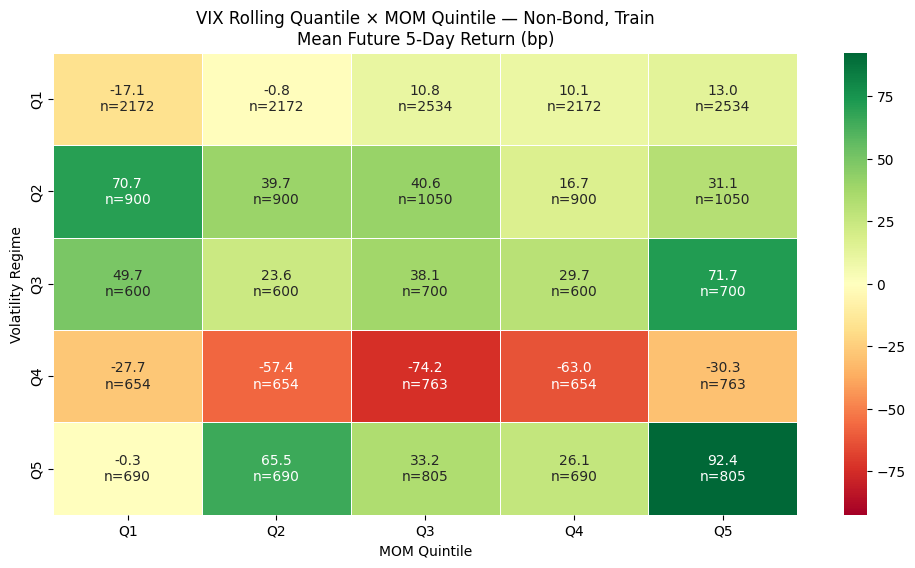

In [119]:
## VIX Rolling Quantile × MOM Quintile

vix_quantile_results = create_conditional_mom_heatmap(
    dataset=conditional_data,
    regime_column='VIX_quantile_group',
    plot_title=(
        'VIX Rolling Quantile × MOM Quintile '
        '— Non-Bond, Train'))

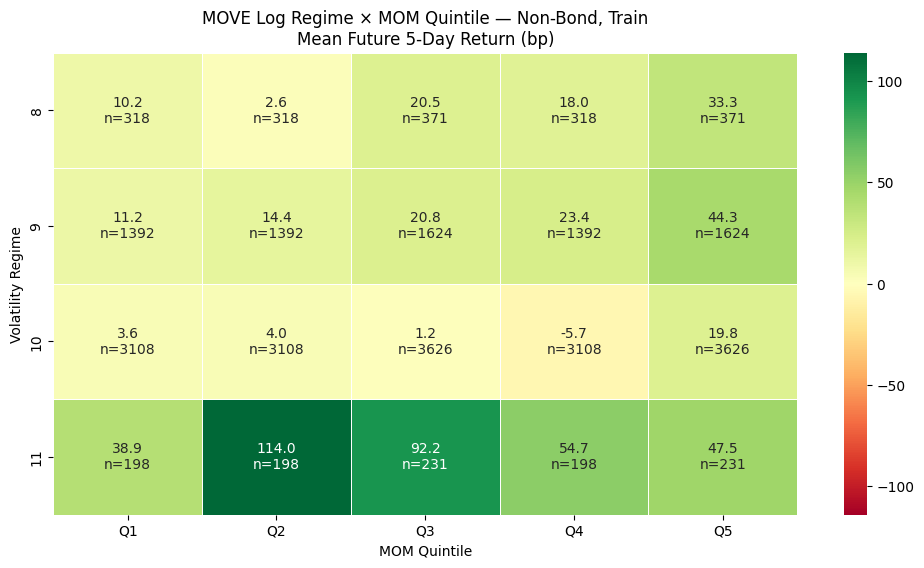

In [120]:
## MOVE Log Regime × MOM Quintile

move_log_results = create_conditional_mom_heatmap(
    dataset=conditional_data,
    regime_column='MOVE_log_group',
    plot_title=(
        'MOVE Log Regime × MOM Quintile '
        '— Non-Bond, Train'
    )
)

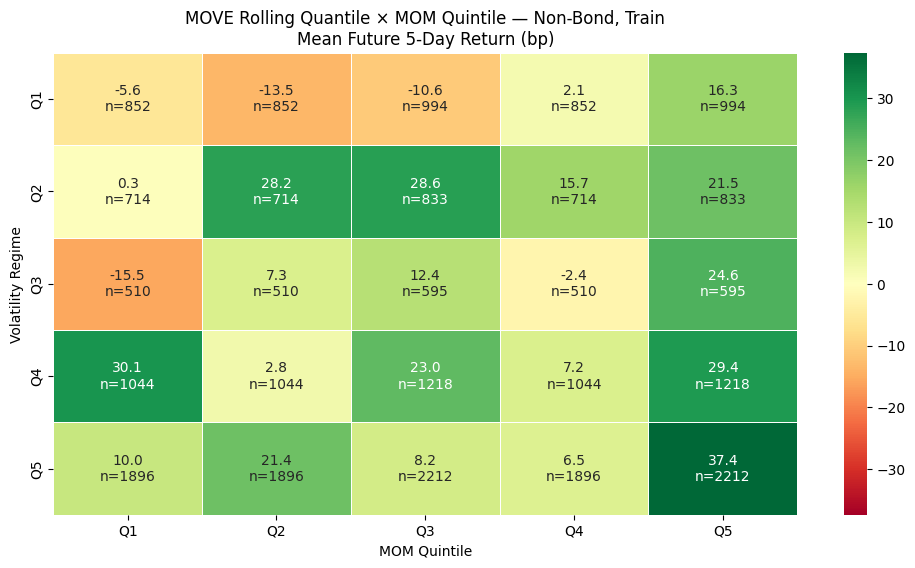

In [121]:
## MOVE Rolling Quantile × MOM Quintile

move_quantile_results = create_conditional_mom_heatmap(
    dataset=conditional_data,
    regime_column='MOVE_quantile_group',
    plot_title=(
        'MOVE Rolling Quantile × MOM Quintile '
        '— Non-Bond, Train'
    )
)

**Measurement 2**

In [122]:
## Residualize MOM beta using VIX beta

import statsmodels.api as sm

BETA_WINDOW = 252

# Calculate daily returns for all assets
asset_returns = close_prices.pct_change(fill_method=None).copy()
asset_returns.index = pd.DatetimeIndex(pd.to_datetime(asset_returns.index, utc=True)).tz_localize(None)

# Exclude bond ETFs and the VIX index
asset_returns = asset_returns.drop(
    columns=[
        ticker
        for ticker in EXCLUDED_TICKERS
        if ticker in asset_returns.columns
    ]
)

# Calculate the daily VIX return
vix_factor_return = index_data[['ts_event', 'VIX']].dropna().copy()
vix_factor_return['VIX_factor_return'] = (vix_factor_return['VIX'].pct_change(fill_method=None))
vix_factor_return = vix_factor_return[['ts_event', 'VIX_factor_return']].dropna()

# Calculate the daily MOM portfolio return
mom_factor_return = mom_signal_portfolio[['ts_event', 'cumulative_return']].dropna().copy()
mom_factor_return['ts_event'] = pd.to_datetime(mom_factor_return['ts_event'],utc=True).dt.tz_localize(None)
mom_factor_return['MOM_factor_return'] = (1 + mom_factor_return['cumulative_return']).pct_change(fill_method=None)
mom_factor_return = mom_factor_return[['ts_event', 'MOM_factor_return']].dropna()

# Align VIX and MOM factor returns
factor_returns = vix_factor_return.merge(mom_factor_return,on='ts_event',how='inner').set_index('ts_event').sort_index()

# Align asset returns with factor-return dates
asset_returns = asset_returns.reindex(factor_returns.index)

display(factor_returns.head())
display(asset_returns.head())

,VIX_factor_return,MOM_factor_return
ts_event,,
2020-02-06,-0.012541,0.002244
2020-02-07,0.034091,0.012101
2020-02-10,-0.027796,0.015093
2020-02-11,0.009309,-0.008558
2020-02-12,-0.094862,-0.015947


ticker,DBA,DBC,DIA,EEM,EFA,EWJ,FXI,GDX,GLD,IWM,...,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
ts_event,,,,,,,,,,,,,,,,,,,,,
2020-02-06,0.007024,0.004124,0.004610,0.001364,0.002592,0.007381,0.005546,0.013547,0.006828,-0.001254,...,0.011582,-0.011609,-0.001927,0.000713,0.004505,0.000312,0.005542,-0.002035,0.000000,-0.002168
2020-02-07,0.004439,-0.005476,-0.011115,-0.015213,-0.009335,-0.009659,-0.011990,-0.015477,0.002374,-0.014654,...,-0.000716,-0.010277,-0.006759,-0.008189,-0.010663,0.003277,0.001002,-0.000582,-0.007322,-0.004734
2020-02-10,-0.001263,-0.009635,0.006943,0.006917,0.004494,-0.001345,0.008981,0.014291,0.000880,0.007345,...,0.011457,-0.002781,0.005185,0.009333,0.017728,0.005288,0.011011,0.003060,0.004270,0.012086
2020-02-11,0.000000,0.004170,0.000990,0.011450,0.003608,0.005220,0.018042,-0.000352,-0.003718,0.007472,...,-0.006549,0.013016,0.005480,0.001067,-0.003266,-0.006343,0.012129,0.006827,0.006668,0.007935
2020-02-12,-0.007585,0.017993,0.004297,0.008603,0.005177,-0.004858,0.004726,-0.005638,0.003121,0.001794,...,0.013006,0.009178,-0.000962,0.008408,0.002880,-0.000934,0.010027,-0.004328,0.001632,0.009325


In [123]:
## Calculate rolling VIX beta and rolling MOM beta

vix_beta = pd.DataFrame(index=asset_returns.index,columns=asset_returns.columns,dtype=float)
mom_beta = pd.DataFrame(index=asset_returns.index,columns=asset_returns.columns,dtype=float)

vix_rolling_variance = (factor_returns['VIX_factor_return'].rolling(window=BETA_WINDOW,min_periods=BETA_WINDOW).var())
mom_rolling_variance = (factor_returns['MOM_factor_return'].rolling(window=BETA_WINDOW,min_periods=BETA_WINDOW).var())

for ticker in asset_returns.columns:
    vix_beta[ticker] = (asset_returns[ticker].rolling(window=BETA_WINDOW,min_periods=BETA_WINDOW).cov(factor_returns['VIX_factor_return']) / vix_rolling_variance)
    mom_beta[ticker] = (asset_returns[ticker].rolling(window=BETA_WINDOW,min_periods=BETA_WINDOW).cov(factor_returns['MOM_factor_return']) /mom_rolling_variance)

vix_beta = vix_beta.replace([np.inf, -np.inf],np.nan)
mom_beta = mom_beta.replace([np.inf, -np.inf],np.nan)

display(vix_beta.dropna().head())
display(mom_beta.dropna().head())

ticker,DBA,DBC,DIA,EEM,EFA,EWJ,FXI,GDX,GLD,IWM,...,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
ts_event,,,,,,,,,,,,,,,,,,,,,
2021-02-08,-0.039017,-0.065484,-0.133353,-0.124693,-0.125647,-0.101545,-0.110798,-0.054710,-0.016836,-0.145585,...,-0.146142,-0.180242,-0.150541,-0.139473,-0.153935,-0.100927,-0.145214,-0.106204,-0.117629,-0.144015
2021-02-09,-0.039011,-0.065458,-0.133333,-0.124659,-0.125619,-0.101469,-0.110713,-0.054643,-0.016780,-0.145604,...,-0.146054,-0.180385,-0.150568,-0.139476,-0.153939,-0.100914,-0.145157,-0.106231,-0.117645,-0.144073
2021-02-10,-0.039072,-0.065436,-0.133239,-0.124493,-0.125563,-0.101399,-0.110598,-0.054461,-0.016795,-0.145504,...,-0.146066,-0.180254,-0.150543,-0.139435,-0.153867,-0.100979,-0.145169,-0.106232,-0.117583,-0.144094
2021-02-11,-0.039090,-0.065527,-0.133134,-0.124502,-0.125570,-0.101522,-0.110824,-0.054041,-0.016662,-0.145360,...,-0.145942,-0.180001,-0.150405,-0.139280,-0.153804,-0.100807,-0.144932,-0.106025,-0.117532,-0.143879
2021-02-12,-0.039078,-0.065778,-0.132939,-0.124350,-0.125494,-0.101434,-0.110663,-0.053913,-0.016589,-0.145245,...,-0.145755,-0.180232,-0.150467,-0.139227,-0.153627,-0.100718,-0.144742,-0.105799,-0.117446,-0.143664


ticker,DBA,DBC,DIA,EEM,EFA,EWJ,FXI,GDX,GLD,IWM,...,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
ts_event,,,,,,,,,,,,,,,,,,,,,
2021-02-08,-0.116956,-0.318634,-0.462422,-0.365395,-0.371349,-0.264085,-0.324286,0.172986,0.060171,-0.419599,...,-0.430977,-0.632831,-0.514071,-0.494626,-0.415049,-0.351725,-0.580492,-0.467543,-0.417131,-0.408333
2021-02-09,-0.116741,-0.318682,-0.462433,-0.365665,-0.371496,-0.264396,-0.324741,0.172950,0.060007,-0.419620,...,-0.431223,-0.632317,-0.514007,-0.494627,-0.414941,-0.351838,-0.580717,-0.467449,-0.417067,-0.408101
2021-02-10,-0.117503,-0.318477,-0.461483,-0.363810,-0.370808,-0.263464,-0.323412,0.175559,0.059915,-0.418273,...,-0.431517,-0.631343,-0.513837,-0.494238,-0.414013,-0.352767,-0.581377,-0.467878,-0.416524,-0.408184
2021-02-11,-0.117507,-0.317491,-0.463652,-0.365550,-0.372300,-0.263626,-0.325277,0.173631,0.059938,-0.420263,...,-0.434255,-0.632513,-0.515887,-0.496887,-0.417646,-0.354523,-0.584624,-0.469606,-0.418104,-0.411017
2021-02-12,-0.117581,-0.316774,-0.464057,-0.364609,-0.372095,-0.263242,-0.323520,0.173520,0.059382,-0.419779,...,-0.435579,-0.630681,-0.515279,-0.497063,-0.418536,-0.355569,-0.583712,-0.469359,-0.417631,-0.410604


In [124]:
## Combine VIX beta and MOM beta into one panel

vix_beta_long = (vix_beta.rename_axis(index='ts_event',columns='ticker').stack().rename('VIX_beta'))
mom_beta_long = (mom_beta.rename_axis(index='ts_event',columns='ticker').stack().rename('MOM_beta'))
beta_panel = pd.concat([vix_beta_long,mom_beta_long],axis=1).dropna().reset_index()

# Use Train data only
beta_panel = beta_panel[(beta_panel['ts_event'] >= pd.Timestamp(TRAIN_START)) &(beta_panel['ts_event'] <= last_valid_train_signal_date)].copy()

display(beta_panel.head())

,ts_event,ticker,VIX_beta,MOM_beta
0,2021-02-08,DBA,-0.039017,-0.116956
1,2021-02-08,DBC,-0.065484,-0.318634
2,2021-02-08,DIA,-0.133353,-0.462422
3,2021-02-08,EEM,-0.124693,-0.365395
4,2021-02-08,EFA,-0.125647,-0.371349


In [125]:
## Regress MOM beta on VIX beta cross-sectionally on every date

residual_data_list = []
daily_beta_regression_results = []

for regression_date, date_data in beta_panel.groupby('ts_event'):
    date_data = date_data[['ts_event','ticker','VIX_beta','MOM_beta']].dropna().copy()

    X = sm.add_constant(date_data[['VIX_beta']])
    y = date_data['MOM_beta']
    beta_regression = sm.OLS(y,X).fit()

    date_data['beta_residual'] = (beta_regression.resid)
    residual_data_list.append(date_data)

    daily_beta_regression_results.append({
        'ts_event': regression_date,
        'alpha': beta_regression.params['const'],
        'VIX_beta_coefficient':
            beta_regression.params['VIX_beta'],
        'r_squared': beta_regression.rsquared,
        'number_of_assets': len(date_data)
    })

beta_residual_data = pd.concat(residual_data_list,ignore_index=True)
daily_beta_regression_results = pd.DataFrame(daily_beta_regression_results)
display(beta_residual_data.head())
display(daily_beta_regression_results.head())

,ts_event,ticker,VIX_beta,MOM_beta,beta_residual
0,2021-02-08,DBA,-0.039017,-0.116956,-0.008638
1,2021-02-08,DBC,-0.065484,-0.318634,-0.111548
2,2021-02-08,DIA,-0.133353,-0.462422,-0.002066
3,2021-02-08,EEM,-0.124693,-0.365395,0.062645
4,2021-02-08,EFA,-0.125647,-0.371349,0.060248


,ts_event,alpha,VIX_beta_coefficient,r_squared,number_of_assets
0,2021-02-08,0.037284,3.731745,0.508655,32
1,2021-02-09,0.037424,3.733062,0.509071,32
2,2021-02-10,0.037330,3.729721,0.507906,32
3,2021-02-11,0.038423,3.754842,0.513158,32
4,2021-02-12,0.038974,3.759376,0.515370,32


In [126]:
## Merge beta residuals with future five-day returns

future_return_panel = conditional_factor[['ts_event','ticker','future_return_5d']].dropna().copy()
residual_return_data = beta_residual_data.merge(future_return_panel,on=['ts_event','ticker'],how='inner')

display(residual_return_data.head())

,ts_event,ticker,VIX_beta,MOM_beta,beta_residual,future_return_5d
0,2021-02-08,DBA,-0.039017,-0.116956,-0.008638,0.011905
1,2021-02-08,DBC,-0.065484,-0.318634,-0.111548,0.026006
2,2021-02-08,DIA,-0.133353,-0.462422,-0.002066,0.004939
3,2021-02-08,EEM,-0.124693,-0.365395,0.062645,0.029292
4,2021-02-08,EFA,-0.125647,-0.371349,0.060248,0.021395


In [127]:
## Divide beta residuals into five cross-sectional quintiles

RESIDUAL_QUINTILE_LABELS = ['Q1','Q2','Q3','Q4','Q5']
residual_return_data['residual_percentile'] = (residual_return_data.groupby('ts_event')['beta_residual'].rank(method='first', pct=True))
residual_return_data['residual_quintile'] = pd.cut(residual_return_data['residual_percentile'],bins=QUANTILE_BINS,labels=RESIDUAL_QUINTILE_LABELS,include_lowest=True)

display(residual_return_data.head())

,ts_event,ticker,VIX_beta,MOM_beta,beta_residual,future_return_5d,residual_percentile,residual_quintile
0,2021-02-08,DBA,-0.039017,-0.116956,-0.008638,0.011905,0.40625,Q3
1,2021-02-08,DBC,-0.065484,-0.318634,-0.111548,0.026006,0.09375,Q1
2,2021-02-08,DIA,-0.133353,-0.462422,-0.002066,0.004939,0.43750,Q3
3,2021-02-08,EEM,-0.124693,-0.365395,0.062645,0.029292,0.68750,Q4
4,2021-02-08,EFA,-0.125647,-0.371349,0.060248,0.021395,0.65625,Q4


In [128]:
## Measure the future-return indication of beta residuals

residual_group_statistics = (residual_return_data.groupby('residual_quintile',observed=False).agg(average_future_return=('future_return_5d','mean'),
        sample_size=('future_return_5d','count')).reset_index())
residual_group_statistics['average_future_return_bp'] = (residual_group_statistics['average_future_return'] * 10000)

display(residual_group_statistics[['residual_quintile','average_future_return_bp',]].round(2))

residual_q1_return = (residual_group_statistics.set_index('residual_quintile').loc['Q1', 'average_future_return_bp'])
residual_q5_return = (residual_group_statistics.set_index('residual_quintile').loc['Q5', 'average_future_return_bp'])
residual_spread = (residual_q5_return - residual_q1_return)

print(f'Residual Q5 minus Q1 spread: 'f'{residual_spread:.2f} bp')

,residual_quintile,average_future_return_bp
0,Q1,6.31
1,Q2,16.96
2,Q3,5.99
3,Q4,10.38
4,Q5,16.38


Residual Q5 minus Q1 spread: 10.07 bp


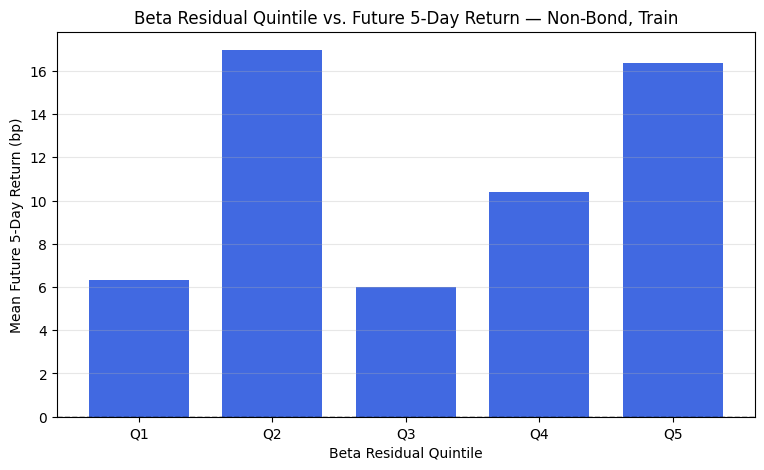

In [129]:
## Plot residual quintiles against future returns

plt.figure(figsize=(9, 5))
plt.bar(
residual_group_statistics[
        'residual_quintile'
    ].astype(str),
    residual_group_statistics[
        'average_future_return_bp'
    ],
    color='royalblue',
    width=0.75
)

plt.axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

plt.xlabel('Beta Residual Quintile')
plt.ylabel('Mean Future 5-Day Return (bp)')
plt.title(
    'Beta Residual Quintile vs. '
    'Future 5-Day Return — Non-Bond, Train'
)
plt.grid(
    axis='y',
    alpha=0.3
)
plt.show()

In [130]:
## Regress future five-day return on beta residual

X = sm.add_constant(residual_return_data[['beta_residual']])
y = residual_return_data['future_return_5d']

residual_return_regression = sm.OLS(y,X).fit(cov_type='cluster',cov_kwds={'groups':residual_return_data['ts_event']})
residual_regression_summary = pd.DataFrame({'coefficient': [residual_return_regression.params['beta_residual']],
    'p_value': [residual_return_regression.pvalues['beta_residual']],
    'confidence_interval_lower': [residual_return_regression.conf_int().loc['beta_residual',0]],
    'confidence_interval_upper': [residual_return_regression.conf_int().loc['beta_residual',1]],
    'r_squared': [residual_return_regression.rsquared]})

display(residual_regression_summary)

,coefficient,p_value,confidence_interval_lower,confidence_interval_upper,r_squared
0,0.002251,0.202495,-0.001211,0.005713,0.000395


# Part 6 — Signal Preprocessing and Lasso Framework

## Objective

Build a time-series modeling framework using the previously developed signals and test the framework with a simple Lasso regression model.

## Steps

1. Apply winsorization, standardization, and normalization to the existing signals.

2. Estimate all preprocessing parameters using only the training data and apply the same parameters to Validation and Test.

3. Use the processed signals as features and future returns as the prediction target.

4. Train a Lasso regression model on Train and use Validation to select its penalty parameter.

5. Evaluate the model using MSE, MAE, RMSE, and prediction IC.

6. Prevent forward-looking bias by preserving chronological order, lagging signals when necessary, and ensuring that future-return labels do not cross dataset boundaries.

In [131]:
## Build the model dataset using the existing signals

from sklearn.linear_model import Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

MODEL_FEATURES = ['MOM', 'MOMRA', 'MACD', 'Smoothed_MACD']
TEST_START = '2025-06-01'
TEST_END = '2026-06-01'

# Keep the existing MOM, MOMRA and future-return data
model_data = factor_data[['ts_event', 'ticker', 'MOM', 'MOMRA', 'future_return_5d']].copy()

# Retrieve the already delayed raw MACD signal
raw_macd_for_model = best_macd_factor_data[['ts_event', 'ticker', 'MACD']].copy()

# Retrieve the already delayed smoothed MACD signal
smoothed_macd_for_model = best_smoothed_factor_data[['ts_event', 'ticker', 'MACD']].rename(columns={'MACD': 'Smoothed_MACD'}).copy()

# Standardize datetime format before merging
model_data['ts_event'] = pd.to_datetime(model_data['ts_event'], utc=True)
raw_macd_for_model['ts_event'] = pd.to_datetime(raw_macd_for_model['ts_event'], utc=True)
smoothed_macd_for_model['ts_event'] = pd.to_datetime(smoothed_macd_for_model['ts_event'], utc=True)

# Merge all existing signals
model_data = model_data.merge(raw_macd_for_model,on=['ts_event', 'ticker'],how='inner').merge(smoothed_macd_for_model,on=['ts_event', 'ticker'],how='inner')
model_data = model_data.replace([np.inf, -np.inf], np.nan).dropna(subset=MODEL_FEATURES + ['future_return_5d']).sort_values(['ts_event', 'ticker']).reset_index(drop=True)

display(model_data.head())

,ts_event,ticker,MOM,MOMRA,future_return_5d,MACD,Smoothed_MACD
0,2021-01-05 00:00:00+00:00,AGG,0.000236,0.602088,-0.011026,0.009785,0.010118
1,2021-01-05 00:00:00+00:00,DBA,0.002165,1.679553,0.007407,0.070613,0.069872
2,2021-01-05 00:00:00+00:00,DBC,0.002297,0.926317,0.023225,0.070863,0.070478
3,2021-01-05 00:00:00+00:00,DIA,0.000491,0.397154,0.024110,0.076755,0.082336
4,2021-01-05 00:00:00+00:00,EEM,0.002313,1.188150,0.023706,0.139848,0.137478


In [132]:
## Add the future-return ending date and create look-ahead-safe time splits

future_end_date_map = pd.Series(pd.to_datetime(close_prices.index, utc=True),index=pd.to_datetime(close_prices.index, utc=True)).shift(-FORWARD_DAYS)
model_data['future_end_date'] = model_data['ts_event'].map(future_end_date_map)

train_start = pd.Timestamp(TRAIN_START, tz='UTC')
validation_start = pd.Timestamp(VALIDATION_START, tz='UTC')
test_start = pd.Timestamp(TEST_START, tz='UTC')
test_end = pd.Timestamp(TEST_END, tz='UTC')

# Train targets must finish before Validation starts
train_model_data = model_data[(model_data['ts_event'] >= train_start) & (model_data['future_end_date'] < validation_start)].copy()

# Validation targets must finish before Test starts
validation_model_data = model_data[(model_data['ts_event'] >= validation_start) & (model_data['future_end_date'] < test_start)].copy()

# Test targets must finish before the final Test date
test_model_data = model_data[(model_data['ts_event'] >= test_start) & (model_data['future_end_date'] <= test_end)].copy()

split_summary = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'Start Date': [
        train_model_data['ts_event'].min(),
        validation_model_data['ts_event'].min(),
        test_model_data['ts_event'].min()
    ],
    'Signal End Date': [
        train_model_data['ts_event'].max(),
        validation_model_data['ts_event'].max(),
        test_model_data['ts_event'].max()
    ],
    'Target End Date': [
        train_model_data['future_end_date'].max(),
        validation_model_data['future_end_date'].max(),
        test_model_data['future_end_date'].max()
    ],
    'Observations': [
        len(train_model_data),
        len(validation_model_data),
        len(test_model_data)
    ]
})

display(split_summary)

,Dataset,Start Date,Signal End Date,Target End Date,Observations
0,Train,2021-01-05 00:00:00+00:00,2024-05-23 00:00:00+00:00,2024-05-31 00:00:00+00:00,31080
1,Validation,2024-06-03 00:00:00+00:00,2025-05-22 00:00:00+00:00,2025-05-30 00:00:00+00:00,9028
2,Test,2025-06-02 00:00:00+00:00,2026-05-22 00:00:00+00:00,2026-06-01 00:00:00+00:00,9102


In [133]:
## Estimate preprocessing parameters using Train data only

preprocessing_parameters = {}

for feature in MODEL_FEATURES:
    lower_bound = train_model_data[feature].quantile(0.01)
    upper_bound = train_model_data[feature].quantile(0.99)
    winsorized_train = train_model_data[feature].clip(lower_bound, upper_bound)

    preprocessing_parameters[feature] = {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'mean': winsorized_train.mean(),
        'std': winsorized_train.std(),
        'min': winsorized_train.min(),
        'max': winsorized_train.max()
    }

display(pd.DataFrame(preprocessing_parameters).T)

,lower_bound,upper_bound,mean,std,min,max
MOM,-0.007560,0.007806,0.000232,0.002629,-0.007560,0.007806
MOMRA,-2.010714,2.404244,0.115525,0.965041,-2.010714,2.404244
MACD,-0.489326,0.226294,0.006863,0.102526,-0.489326,0.226294
Smoothed_MACD,-0.490475,0.226819,0.006863,0.102178,-0.490475,0.226819


In [134]:
## Apply winsorization, standardization and normalization

def preprocess_signals(dataset, feature_names, parameters):
    processed_data = dataset.copy()

    for feature in feature_names:
        p = parameters[feature]

        # Winsorization
        processed_data[f'{feature}_winsorized'] = processed_data[feature].clip(lower=p['lower_bound'],upper=p['upper_bound'])

        # Standardization after winsorization
        processed_data[f'{feature}_standardized'] = (processed_data[f'{feature}_winsorized'] - p['mean']) / p['std']

        # Min-max normalization after winsorization
        feature_range = p['max'] - p['min']
        processed_data[f'{feature}_normalized'] = (processed_data[f'{feature}_winsorized'] - p['min']) / feature_range

    return processed_data


train_processed = preprocess_signals(train_model_data,MODEL_FEATURES,preprocessing_parameters)
validation_processed = preprocess_signals(validation_model_data,MODEL_FEATURES,preprocessing_parameters)
test_processed = preprocess_signals(test_model_data,MODEL_FEATURES,preprocessing_parameters)

display(train_processed.head())

,ts_event,ticker,MOM,MOMRA,future_return_5d,MACD,Smoothed_MACD,future_end_date,MOM_winsorized,MOM_standardized,MOM_normalized,MOMRA_winsorized,MOMRA_standardized,MOMRA_normalized,MACD_winsorized,MACD_standardized,MACD_normalized,Smoothed_MACD_winsorized,Smoothed_MACD_standardized,Smoothed_MACD_normalized
0,2021-01-05 00:00:00+00:00,AGG,0.000236,0.602088,-0.011026,0.009785,0.010118,2021-01-12 00:00:00+00:00,0.000236,0.001433,0.507364,0.602088,0.504190,0.591807,0.009785,0.028507,0.697453,0.010118,0.031861,0.697891
1,2021-01-05 00:00:00+00:00,DBA,0.002165,1.679553,0.007407,0.070613,0.069872,2021-01-12 00:00:00+00:00,0.002165,0.735330,0.632919,1.679553,1.620686,0.835855,0.070613,0.621793,0.782452,0.069872,0.616665,0.781196
2,2021-01-05 00:00:00+00:00,DBC,0.002297,0.926317,0.023225,0.070863,0.070478,2021-01-12 00:00:00+00:00,0.002297,0.785543,0.641510,0.926317,0.840163,0.665245,0.070863,0.624232,0.782801,0.070478,0.622588,0.782040
3,2021-01-05 00:00:00+00:00,DIA,0.000491,0.397154,0.024110,0.076755,0.082336,2021-01-12 00:00:00+00:00,0.000491,0.098358,0.523946,0.397154,0.291831,0.545389,0.076755,0.681705,0.791035,0.082336,0.738645,0.798572
4,2021-01-05 00:00:00+00:00,EEM,0.002313,1.188150,0.023706,0.139848,0.137478,2021-01-12 00:00:00+00:00,0.002313,0.791578,0.642542,1.188150,1.111482,0.724551,0.139848,1.297091,0.879201,0.137478,1.278310,0.875447


In [135]:
## Check the processed Train signals

preprocessing_summary = []

for feature in MODEL_FEATURES:
    for transformation, column in {
        'Raw': feature,
        'Winsorized': f'{feature}_winsorized',
        'Standardized': f'{feature}_standardized',
        'Normalized': f'{feature}_normalized'
    }.items():
        preprocessing_summary.append({
            'Signal': feature,
            'Transformation': transformation,
            'Mean': train_processed[column].mean(),
            'Standard Deviation': train_processed[column].std(),
            'Minimum': train_processed[column].min(),
            'Maximum': train_processed[column].max()
        })

preprocessing_summary = pd.DataFrame(preprocessing_summary)

display(
    preprocessing_summary.style.format({
        'Mean': '{:.4f}',
        'Standard Deviation': '{:.4f}',
        'Minimum': '{:.4f}',
        'Maximum': '{:.4f}'
    })
)

,Signal,Transformation,Mean,Standard Deviation,Minimum,Maximum
0,MOM,Raw,0.0002,0.0029,-0.0318,0.0222
1,MOM,Winsorized,0.0002,0.0026,-0.0076,0.0078
2,MOM,Standardized,0.0000,1.0000,-2.9642,2.8810
3,MOM,Normalized,0.5071,0.1711,0.0000,1.0000
4,MOMRA,Raw,0.1155,0.9810,-3.5909,4.0973
5,MOMRA,Winsorized,0.1155,0.9650,-2.0107,2.4042
6,MOMRA,Standardized,0.0000,1.0000,-2.2033,2.3716
7,MOMRA,Normalized,0.4816,0.2186,0.0000,1.0000
8,MACD,Raw,0.0033,0.1316,-1.6034,0.4598
9,MACD,Winsorized,0.0069,0.1025,-0.4893,0.2263


In [136]:
## Prepare standardized features for all models

MODEL_INPUT_FEATURES = [
    f'{feature}_standardized'
    for feature in MODEL_FEATURES
]

X_train = train_processed[MODEL_INPUT_FEATURES]
y_train = train_processed['future_return_5d']

X_validation = validation_processed[MODEL_INPUT_FEATURES]
y_validation = validation_processed['future_return_5d']

X_test = test_processed[MODEL_INPUT_FEATURES]
y_test = test_processed['future_return_5d']

print('Train:', X_train.shape)
print('Validation:', X_validation.shape)
print('Test:', X_test.shape)

Train: (31080, 4)
Validation: (9028, 4)
Test: (9102, 4)


In [137]:
## Select the Lasso penalty using Validation data only

lasso_alpha_results = []

for alpha in np.logspace(-7, -3, 30):
    model = Lasso(alpha=alpha, max_iter=50000)
    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    validation_prediction = model.predict(X_validation)

    lasso_alpha_results.append({
        'alpha': alpha,
        'train_mse': mean_squared_error(y_train,train_prediction),
        'validation_mse': mean_squared_error(y_validation,validation_prediction),
        'validation_mae': mean_absolute_error(y_validation,validation_prediction),
        'validation_ic': np.corrcoef(validation_prediction,y_validation)[0, 1],
        'nonzero_coefficients': np.count_nonzero(model.coef_)})

lasso_alpha_results = pd.DataFrame(lasso_alpha_results).sort_values('validation_mse').reset_index(drop=True)
best_lasso_alpha = lasso_alpha_results.loc[0, 'alpha']

print(f'Best Lasso alpha: {best_lasso_alpha:.10f}')
display(
    lasso_alpha_results.head(10).style.format({
        'alpha': '{:.10f}',
        'train_mse': '{:.12f}',
        'validation_mse': '{:.12f}',
        'validation_mae': '{:.12f}',
        'validation_ic': '{:.6f}',
        'nonzero_coefficients': '{:.0f}'
    })
)

Best Lasso alpha: 0.0000221222


,alpha,train_mse,validation_mse,validation_mae,validation_ic,nonzero_coefficients
0,0.0000221222,0.000928880903,0.000918706932,0.020403229509,0.052733,3
1,0.0000303920,0.000928882683,0.000918711275,0.020403527555,0.054449,2
2,0.0000417532,0.000928885729,0.000918718158,0.020403941242,0.056970,2
3,0.0000573615,0.000928891479,0.000918728927,0.020404533945,0.060787,2
4,0.0000788046,0.000928902330,0.000918746181,0.020405373417,0.066736,2
5,0.0001082637,0.000928922811,0.000918774536,0.020406550251,0.076092,2
6,0.0001487352,0.000928933775,0.000918927823,0.020408853457,0.076409,1
7,0.0000161026,0.000928696116,0.000918972678,0.020406532176,0.035491,3
8,0.0002043360,0.000928953406,0.000919146546,0.020412110043,0.076409,1
9,0.0000117210,0.000928595508,0.000919211885,0.020409901929,0.023080,3


,Signal,Coefficient
0,Smoothed_MACD,0.000164
1,MOMRA,-0.000000
2,MACD,-0.000002
3,MOM,-0.000388


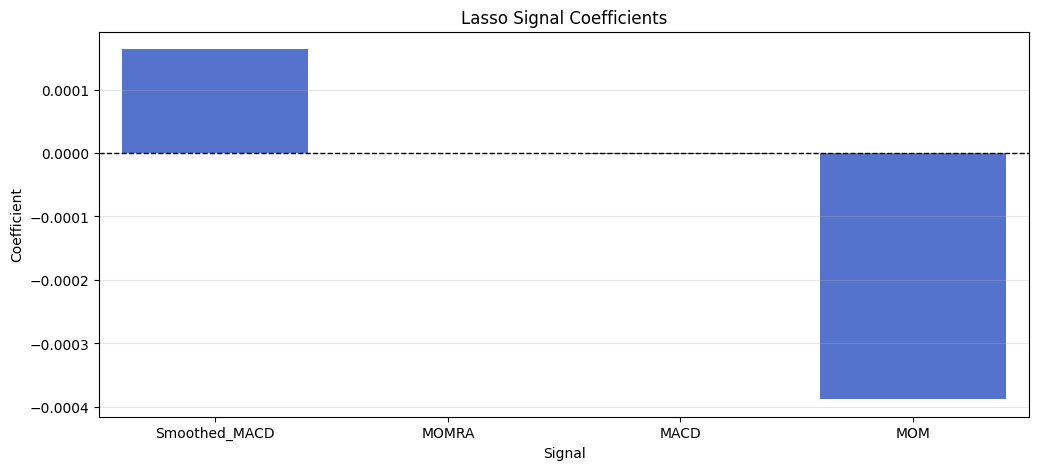

In [138]:
## Fit the selected Lasso model

best_lasso_model = Lasso(alpha=best_lasso_alpha,max_iter=50000)
best_lasso_model.fit(X_train, y_train)

lasso_coefficients = pd.DataFrame({'Signal': MODEL_FEATURES,'Coefficient': best_lasso_model.coef_}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

display(lasso_coefficients)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=lasso_coefficients,
    x='Signal',
    y='Coefficient',
    color='royalblue'
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Lasso Signal Coefficients')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [139]:
## Evaluate the Lasso model without using Test for model selection

def evaluate_predictions(actual_return,predicted_return,model_name,dataset_name):
    mse = mean_squared_error(actual_return,predicted_return)
    mae = mean_absolute_error(actual_return,predicted_return)
    prediction_ic = np.corrcoef(predicted_return,actual_return)[0, 1]

    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'MSE': mse,
        'MAE': mae,
        'RMSE': np.sqrt(mse),
        'Prediction IC': prediction_ic
    }

In [140]:
## Generate Lasso predictions

lasso_train_prediction = best_lasso_model.predict(X_train)
lasso_validation_prediction = best_lasso_model.predict(X_validation)
lasso_test_prediction = best_lasso_model.predict(X_test)

In [141]:
## Evaluate Lasso on Train and Validation

lasso_performance = pd.DataFrame([
    evaluate_predictions(
        actual_return=y_train,
        predicted_return=lasso_train_prediction,
        model_name='Lasso',
        dataset_name='Train'
    ),

    evaluate_predictions(
        actual_return=y_validation,
        predicted_return=lasso_validation_prediction,
        model_name='Lasso',
        dataset_name='Validation'
    )
])

display(
    lasso_performance.style.format({
        'MSE': '{:.12f}',
        'MAE': '{:.12f}',
        'RMSE': '{:.6%}',
        'Prediction IC': '{:.6f}'
    })
)

,Model,Dataset,MSE,MAE,RMSE,Prediction IC
0,Lasso,Train,0.000928880903,0.020658265813,3.047755%,0.012471
1,Lasso,Validation,0.000918706932,0.020403229509,3.031018%,0.052733


# Part 7 — Multi-Model Comparison and Selection

## Objective

Generalize the existing modeling framework to support multiple model families and select the best model using Validation performance.

## Steps

1. Apply the same Train, Validation, and Test framework to all candidate models.

2. Evaluate at least:
   - An Equal-Weights benchmark
   - One regression model, such as Lasso
   - One tree-based model, such as Random Forest

3. Train each model using only the training data.

4. Generate predictions and conduct a complete backtest on the same Validation period.

5. Compare the models primarily using Validation MSE and MAE.

6. Select the best-performing model based only on Validation results and reserve Test for final out-of-sample evaluation.



In [142]:
## Equal-Weights signal model

equal_weight_train_score = X_train.mean(axis=1)
equal_weight_validation_score = X_validation.mean(axis=1)
equal_weight_test_score = X_test.mean(axis=1)

equal_weight_calibrator = LinearRegression()
equal_weight_calibrator.fit(equal_weight_train_score.to_numpy().reshape(-1, 1),y_train)

equal_weight_train_prediction = (equal_weight_calibrator.predict(equal_weight_train_score.to_numpy().reshape(-1, 1)))
equal_weight_validation_prediction = (equal_weight_calibrator.predict(equal_weight_validation_score.to_numpy().reshape(-1, 1)))
equal_weight_test_prediction = (equal_weight_calibrator.predict(equal_weight_test_score.to_numpy().reshape(-1, 1)))

In [143]:
## Select Random Forest parameters using Validation MSE

random_forest_results = []
random_forest_models = {}

for max_depth in [3, 5, 8]:
    for min_samples_leaf in [20, 50, 100]:

        model = RandomForestRegressor(n_estimators=200,max_depth=max_depth,min_samples_leaf=min_samples_leaf,max_features='sqrt',random_state=42,n_jobs=-1)
        model.fit(X_train, y_train)

        validation_prediction = model.predict(X_validation)

        parameter_key = (max_depth,min_samples_leaf)
        random_forest_models[parameter_key] = model

        random_forest_results.append({'max_depth': max_depth,'min_samples_leaf': min_samples_leaf,'validation_mse': mean_squared_error(y_validation,validation_prediction),
            'validation_mae': mean_absolute_error(y_validation,validation_prediction),'validation_ic': np.corrcoef(validation_prediction,y_validation)[0, 1]})

random_forest_results = (pd.DataFrame(random_forest_results).sort_values(['validation_mse', 'validation_mae']).reset_index(drop=True))

best_rf_depth = int(random_forest_results.loc[0, 'max_depth'])
best_rf_leaf = int(random_forest_results.loc[0, 'min_samples_leaf'])
best_random_forest_model = random_forest_models[(best_rf_depth, best_rf_leaf)]

display(
    random_forest_results.style.format({
        'validation_mse': '{:.12f}',
        'validation_mae': '{:.12f}',
        'validation_ic': '{:.6f}'
    })
)

print('Best max depth:', best_rf_depth)
print('Best minimum leaf size:', best_rf_leaf)

,max_depth,min_samples_leaf,validation_mse,validation_mae,validation_ic
0,3,100,0.000918108816,0.020417799725,0.046442
1,3,50,0.000918462653,0.020412170174,0.041730
2,5,100,0.000919147775,0.020442509804,0.036080
3,3,20,0.000919727931,0.020410733968,0.029913
4,5,50,0.000920191194,0.020436782661,0.031211
5,8,100,0.000920251216,0.020473435240,0.033437
6,8,20,0.000920295486,0.020421793891,0.051201
7,5,20,0.000921020086,0.020420417875,0.032446
8,8,50,0.000921795940,0.020466923215,0.031483


Best max depth: 3
Best minimum leaf size: 100


In [144]:
rf_train_prediction = ( best_random_forest_model.predict(X_train))
rf_validation_prediction = (best_random_forest_model.predict(X_validation))
rf_test_prediction = (best_random_forest_model.predict(X_test))

In [145]:
## Compare models using Validation only

validation_model_comparison = pd.DataFrame([evaluate_predictions(y_validation,equal_weight_validation_prediction,'Equal Weights','Validation'),
    evaluate_predictions(y_validation,lasso_validation_prediction,'Lasso','Validation'),
    evaluate_predictions(y_validation,rf_validation_prediction,'Random Forest','Validation')])

validation_model_comparison = (validation_model_comparison.sort_values(['MSE', 'MAE']).reset_index(drop=True))

display(
    validation_model_comparison.style.format({
        'MSE': '{:.12f}',
        'MAE': '{:.12f}',
        'RMSE': '{:.6%}',
        'Prediction IC': '{:.6f}'
    })
)

,Model,Dataset,MSE,MAE,RMSE,Prediction IC
0,Random Forest,Validation,0.000918108816,0.020417799725,3.030031%,0.046442
1,Lasso,Validation,0.000918706932,0.020403229509,3.031018%,0.052733
2,Equal Weights,Validation,0.000918893801,0.020410433687,3.031326%,0.087557


In [146]:
def predictions_to_matrix(processed_dataset,predictions):
    prediction_data = (processed_dataset[['ts_event', 'ticker']].copy())
    prediction_data['prediction'] = predictions
    prediction_matrix = prediction_data.pivot(index='ts_event',columns='ticker',values='prediction').sort_index()

    return prediction_matrix

equal_weight_validation_matrix = predictions_to_matrix(validation_processed,equal_weight_validation_prediction)
lasso_validation_matrix = predictions_to_matrix(validation_processed,lasso_validation_prediction)
rf_validation_matrix = predictions_to_matrix(validation_processed,rf_validation_prediction)

In [147]:
validation_common_dates = (get_valid_signal_dates(equal_weight_validation_matrix).intersection(get_valid_signal_dates(lasso_validation_matrix)).intersection(
    get_valid_signal_dates(rf_validation_matrix)))

validation_rebalance_dates = (validation_common_dates[::HOLDING_PERIOD])

print(
    'Number of Validation rebalance dates:',
    len(validation_rebalance_dates)
)

Number of Validation rebalance dates: 49


In [148]:
equal_weight_model_weights = convert_signal_to_weights(
    signal_matrix=equal_weight_validation_matrix,
    target_gross_exposure=TARGET_GROSS_EXPOSURE,
    rebalance_dates=validation_rebalance_dates
)

lasso_model_weights = convert_signal_to_weights(
    signal_matrix=lasso_validation_matrix,
    target_gross_exposure=TARGET_GROSS_EXPOSURE,
    rebalance_dates=validation_rebalance_dates
)

rf_model_weights = convert_signal_to_weights(
    signal_matrix=rf_validation_matrix,
    target_gross_exposure=TARGET_GROSS_EXPOSURE,
    rebalance_dates=validation_rebalance_dates
)

In [149]:
_, equal_weight_model_portfolio = multi_asset_backtester(
    data=data_common,
    weights=equal_weight_model_weights,
    capital=CAPITAL,
    delay=DELAY
)

_, lasso_model_portfolio = multi_asset_backtester(
    data=data_common,
    weights=lasso_model_weights,
    capital=CAPITAL,
    delay=DELAY
)

_, rf_model_portfolio = multi_asset_backtester(
    data=data_common,
    weights=rf_model_weights,
    capital=CAPITAL,
    delay=DELAY
)

In [150]:
def calculate_backtest_metrics(portfolio_summary,start_date,end_date,model_name):
    curve = prepare_portfolio_curve(portfolio_summary,start_date,end_date)
    curve['daily_return'] = (1 + curve['cumulative_return']).pct_change(fill_method=None)

    daily_return = curve['daily_return'].dropna()
    total_return = curve['cumulative_return'].iloc[-1]

    annualized_volatility = (daily_return.std() * np.sqrt(252))

    if daily_return.std() > 0:
        sharpe_ratio = (daily_return.mean() / daily_return.std() * np.sqrt(252))
    else:
        sharpe_ratio = np.nan

    wealth_index = (1 + curve['cumulative_return'])
    running_maximum = wealth_index.cummax()
    drawdown = (wealth_index / running_maximum - 1)

    return {
        'Model': model_name,
        'Validation Total Return': total_return,
        'Validation Annualized Volatility':
            annualized_volatility,
        'Validation Sharpe': sharpe_ratio,
        'Validation Maximum Drawdown':
            drawdown.min()
    }

In [151]:
validation_backtest_comparison = pd.DataFrame([
    calculate_backtest_metrics(
        equal_weight_model_portfolio,
        VALIDATION_START,
        VALIDATION_END,
        'Equal Weights'
    ),

    calculate_backtest_metrics(
        lasso_model_portfolio,
        VALIDATION_START,
        VALIDATION_END,
        'Lasso'
    ),

    calculate_backtest_metrics(
        rf_model_portfolio,
        VALIDATION_START,
        VALIDATION_END,
        'Random Forest'
    )
])

display(
    validation_backtest_comparison.style.format({
        'Validation Total Return': '{:.2%}',
        'Validation Annualized Volatility': '{:.2%}',
        'Validation Sharpe': '{:.4f}',
        'Validation Maximum Drawdown': '{:.2%}'
    })
)

,Model,Validation Total Return,Validation Annualized Volatility,Validation Sharpe,Validation Maximum Drawdown
0,Equal Weights,18.05%,18.50%,1.0113,-10.11%
1,Lasso,5.82%,20.50%,0.3848,-17.48%
2,Random Forest,-7.84%,28.97%,-0.1454,-27.96%


In [152]:
final_validation_comparison = (validation_model_comparison.merge(validation_backtest_comparison,on='Model',how='left')
    .sort_values(['MSE', 'MAE'])
    .reset_index(drop=True)
)

display(
    final_validation_comparison.style.format({
        'MSE': '{:.12f}',
        'MAE': '{:.12f}',
        'RMSE': '{:.6%}',
        'Prediction IC': '{:.6f}',
        'Validation Total Return': '{:.2%}',
        'Validation Annualized Volatility': '{:.2%}',
        'Validation Sharpe': '{:.4f}',
        'Validation Maximum Drawdown': '{:.2%}'
    })
)

,Model,Dataset,MSE,MAE,RMSE,Prediction IC,Validation Total Return,Validation Annualized Volatility,Validation Sharpe,Validation Maximum Drawdown
0,Random Forest,Validation,0.000918108816,0.020417799725,3.030031%,0.046442,-7.84%,28.97%,-0.1454,-27.96%
1,Lasso,Validation,0.000918706932,0.020403229509,3.031018%,0.052733,5.82%,20.50%,0.3848,-17.48%
2,Equal Weights,Validation,0.000918893801,0.020410433687,3.031326%,0.087557,18.05%,18.50%,1.0113,-10.11%


In [153]:

best_model_name = final_validation_comparison.loc[0, 'Model']

print('Best model selected using Validation MSE:',best_model_name)

test_predictions = {
    'Equal Weights': equal_weight_test_prediction,
    'Lasso': lasso_test_prediction,
    'Random Forest': rf_test_prediction
}

selected_test_prediction = test_predictions[best_model_name]

final_test_result = pd.DataFrame([
    evaluate_predictions(
        y_test,
        selected_test_prediction,
        best_model_name,
        'Test'
    )
])

display(
    final_test_result.style.format({
        'MSE': '{:.12f}',
        'MAE': '{:.12f}',
        'RMSE': '{:.6%}',
        'Prediction IC': '{:.6f}'
    })
)

Best model selected using Validation MSE: Random Forest


,Model,Dataset,MSE,MAE,RMSE,Prediction IC
0,Random Forest,Test,0.000978356450,0.018856095254,3.127869%,-0.009378


# Part 8 — Portfolio Optimization Framework

## Objective

Build a flexible portfolio optimization framework that converts multi-asset return predictions and estimated risks into portfolio weights.

## Steps

1. Calculate prediction residuals as the difference between actual and predicted returns.

2. Estimate the cross-asset covariance matrix using the prediction residuals.

3. For each rebalancing date, use:
   - A vector of predicted returns for all assets
   - A residual covariance matrix for all assets

4. Pass these multi-dimensional inputs into the optimizer rather than optimizing one asset or one scalar prediction at a time.

5. Return a vector of optimized portfolio weights subject to the required exposure and position constraints.

6. Keep the optimization framework flexible so that the objective function, constraints, and risk preferences can be modified later.

In [154]:
## Select predictions from the model chosen by Validation MSE

train_prediction_dictionary = {'Equal Weights': equal_weight_train_prediction, 'Lasso': lasso_train_prediction, 'Random Forest': rf_train_prediction}
validation_prediction_dictionary = {'Equal Weights': equal_weight_validation_prediction, 'Lasso': lasso_validation_prediction, 'Random Forest': rf_validation_prediction}

selected_train_prediction = train_prediction_dictionary[best_model_name]
selected_validation_prediction = validation_prediction_dictionary[best_model_name]

print('Selected prediction model:', best_model_name)

Selected prediction model: Random Forest


In [155]:
## Estimate covariance matrix using Train residuals only

def estimate_residual_covariance(processed_dataset, predictions):
    residual_data = processed_dataset[['ts_event', 'ticker', 'future_return_5d']].copy()
    residual_data['prediction'] = np.asarray(predictions)
    residual_data['residual'] = residual_data['future_return_5d'] - residual_data['prediction']
    residual_matrix = residual_data.pivot(index='ts_event', columns='ticker', values='residual').sort_index().dropna(how='any')
    residual_covariance_matrix = residual_matrix.cov()
    return residual_data, residual_matrix, residual_covariance_matrix

train_residual_data, train_residual_matrix, residual_covariance_matrix = estimate_residual_covariance(train_processed, selected_train_prediction)

print('Residual matrix shape:', train_residual_matrix.shape)
print('Covariance matrix shape:', residual_covariance_matrix.shape)
display(residual_covariance_matrix.iloc[:5, :5])


Residual matrix shape: (840, 37)
Covariance matrix shape: (37, 37)


ticker,AGG,DBA,DBC,DIA,EEM
ticker,,,,,
AGG,0.000081,-0.000018,-0.000022,0.000056,0.000072
DBA,-0.000018,0.000485,0.000342,0.000058,0.000064
DBC,-0.000022,0.000342,0.000840,0.000135,0.000187
DIA,0.000056,0.000058,0.000135,0.000394,0.000309
EEM,0.000072,0.000064,0.000187,0.000309,0.000641


In [156]:
## Stable mean-variance optimization with linear constraints

from scipy.optimize import minimize, LinearConstraint, Bounds

def optimize_portfolio(expected_returns, covariance_matrix, risk_aversion=10.0, target_gross_exposure=2.0, maximum_absolute_weight=0.20):
    asset_names = expected_returns.index
    mu = expected_returns.to_numpy(dtype=float)
    sigma = covariance_matrix.loc[asset_names, asset_names].to_numpy(dtype=float)
    sigma = (sigma + sigma.T) / 2

    number_of_assets = len(asset_names)

    # Decision variables:
    # first N values = portfolio weights
    # last N values = absolute-weight auxiliary variables
    def objective(decision_variables):
        weights = decision_variables[:number_of_assets]
        return 0.5 * risk_aversion * (weights @ sigma @ weights) - weights @ mu

    def objective_gradient(decision_variables):
        weights = decision_variables[:number_of_assets]
        weight_gradient = risk_aversion * sigma @ weights - mu
        auxiliary_gradient = np.zeros(number_of_assets)
        return np.concatenate([weight_gradient, auxiliary_gradient])

    identity_matrix = np.eye(number_of_assets)
    zero_matrix = np.zeros((number_of_assets, number_of_assets))

    # Net exposure: sum(weights) = 0
    net_exposure_row = np.concatenate([
        np.ones(number_of_assets),
        np.zeros(number_of_assets)
    ]).reshape(1, -1)

    # Gross exposure: sum(auxiliary variables) <= target
    gross_exposure_row = np.concatenate([
        np.zeros(number_of_assets),
        np.ones(number_of_assets)
    ]).reshape(1, -1)

    # auxiliary >= weights
    positive_absolute_constraint = np.concatenate([
        -identity_matrix,
        identity_matrix
    ], axis=1)

    # auxiliary >= -weights
    negative_absolute_constraint = np.concatenate([
        identity_matrix,
        identity_matrix
    ], axis=1)

    # Equality constraint: net exposure must equal zero
    equality_constraint = LinearConstraint(
        net_exposure_row,
        lb=np.array([0.0]),
        ub=np.array([0.0]))

    # Inequality constraints
    inequality_constraint_matrix = np.vstack([
        gross_exposure_row,
        positive_absolute_constraint,
        negative_absolute_constraint])

    inequality_lower_bounds = np.concatenate([[-np.inf], np.zeros(number_of_assets), np.zeros(number_of_assets)])

    inequality_upper_bounds = np.concatenate([[target_gross_exposure],np.full(number_of_assets, np.inf),np.full(number_of_assets, np.inf)])

    inequality_constraint = LinearConstraint(inequality_constraint_matrix,lb=inequality_lower_bounds,ub=inequality_upper_bounds)

    variable_lower_bounds = np.concatenate([
        np.full(number_of_assets, -maximum_absolute_weight),
        np.zeros(number_of_assets)
    ])

    variable_upper_bounds = np.concatenate([
        np.full(number_of_assets, maximum_absolute_weight),
        np.full(number_of_assets, maximum_absolute_weight)
    ])

    variable_bounds = Bounds(
        variable_lower_bounds,
        variable_upper_bounds
    )

    initial_values = np.zeros(2 * number_of_assets)

    result = minimize(
        fun=objective,
        x0=initial_values,
        jac=objective_gradient,
        method='SLSQP',
        bounds=variable_bounds,
        constraints=[equality_constraint, inequality_constraint],
        options={
            'maxiter': 3000,
            'ftol': 1e-9,
            'disp': False
        }
    )

    if not result.success:
        raise RuntimeError(
            'Portfolio optimization failed: '
            + result.message
        )

    optimized_weights = result.x[:number_of_assets]

    return pd.Series(
        optimized_weights,
        index=asset_names,
        name='weight'
    )

In [157]:
## Generate optimized weights on every Validation rebalance date

selected_validation_matrix = predictions_to_matrix(validation_processed, selected_validation_prediction)

optimization_tickers = selected_validation_matrix.columns.intersection(residual_covariance_matrix.columns)
selected_validation_matrix = selected_validation_matrix[optimization_tickers]
optimization_covariance_matrix = residual_covariance_matrix.loc[optimization_tickers, optimization_tickers]

optimization_valid_dates = selected_validation_matrix.dropna(how='any').index
optimization_rebalance_dates = optimization_valid_dates[::HOLDING_PERIOD]

optimized_weight_list = []

for rebalance_date in optimization_rebalance_dates:
    expected_return_vector = selected_validation_matrix.loc[rebalance_date]
    optimized_weights = optimize_portfolio(expected_return_vector, optimization_covariance_matrix, risk_aversion=10.0, target_gross_exposure=TARGET_GROSS_EXPOSURE, maximum_absolute_weight=0.20)
    optimized_weights.name = rebalance_date
    optimized_weight_list.append(optimized_weights)

optimized_validation_weights = pd.DataFrame(optimized_weight_list)
optimized_validation_weights.index.name = 'ts_event'

print('Optimized weight table shape:', optimized_validation_weights.shape)
display(optimized_validation_weights.head())

Optimized weight table shape: (49, 37)


ticker,AGG,DBA,DBC,DIA,EEM,EFA,EWJ,FXI,GDX,GLD,...,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
ts_event,,,,,,,,,,,,,,,,,,,,,
2024-06-03 00:00:00+00:00,2.246736e-17,1.202927e-01,-1.823190e-18,-1.993415e-01,-1.062193e-01,-2.595480e-17,1.509468e-17,1.621499e-17,-3.317600e-02,4.351864e-18,...,-2.107800e-17,7.038477e-06,0.139792,-1.501267e-17,2.407695e-03,-2.311040e-18,-2.709855e-18,1.734560e-01,-4.963891e-02,-2.000000e-01
2024-06-10 00:00:00+00:00,-2.240357e-17,1.793263e-01,-6.121241e-02,-1.364377e-01,-1.409767e-01,2.777082e-02,5.792141e-19,-2.214096e-17,-5.376082e-03,2.791770e-17,...,4.555549e-02,-6.623181e-18,0.046541,3.983838e-18,3.752439e-02,2.748119e-18,-1.190164e-17,3.951958e-18,-1.672508e-18,-2.000000e-01
2024-06-17 00:00:00+00:00,2.826091e-17,2.000000e-01,-1.179441e-01,-1.122303e-18,-6.495915e-02,-1.054881e-18,-4.543561e-02,5.005144e-03,-1.654296e-17,1.100547e-01,...,-9.964768e-17,1.500936e-02,0.080467,-1.116460e-19,9.544491e-02,-6.483479e-02,-4.744874e-02,3.415003e-02,-3.721007e-02,-2.000000e-01
2024-06-25 00:00:00+00:00,5.048000e-19,1.158911e-01,-2.000000e-01,-1.169393e-17,-1.504639e-17,-1.054679e-01,-1.093910e-01,8.239118e-19,1.226423e-19,1.436339e-01,...,1.572703e-02,-7.124757e-02,0.120758,-8.191887e-18,-1.082315e-17,-5.033854e-02,-9.461234e-03,1.023213e-17,-3.646933e-18,-2.826213e-02
2024-07-02 00:00:00+00:00,2.128587e-18,2.215415e-18,-2.000000e-01,1.359483e-18,6.572781e-02,-2.000000e-01,-1.890061e-04,-2.931053e-02,3.463258e-04,1.641016e-01,...,7.462686e-02,-5.167037e-02,0.078947,-1.645074e-17,1.561181e-01,-7.011282e-02,-8.023776e-18,3.007369e-02,-5.724358e-18,3.884756e-17


In [158]:
## Check optimization input and output dimensions

example_date = optimization_rebalance_dates[0]
example_expected_return_vector = selected_validation_matrix.loc[example_date]
example_weight_vector = optimized_validation_weights.loc[example_date]

optimization_dimension_check = pd.DataFrame({
    'Object': ['Expected Return Vector', 'Residual Covariance Matrix', 'Optimized Weight Vector'],
    'Shape': [str(example_expected_return_vector.shape), str(optimization_covariance_matrix.shape), str(example_weight_vector.shape)]
})

display(optimization_dimension_check)

,Object,Shape
0,Expected Return Vector,"(37,)"
1,Residual Covariance Matrix,"(37, 37)"
2,Optimized Weight Vector,"(37,)"


In [159]:
## Check optimized portfolio constraints

optimization_weight_checks = pd.DataFrame({
    'Net Exposure': optimized_validation_weights.sum(axis=1),
    'Gross Exposure': optimized_validation_weights.abs().sum(axis=1),
    'Maximum Absolute Weight': optimized_validation_weights.abs().max(axis=1)
})

display(optimization_weight_checks.describe().style.format({
    'Net Exposure': '{:.8f}',
    'Gross Exposure': '{:.6f}',
    'Maximum Absolute Weight': '{:.6f}'
}))

,Net Exposure,Gross Exposure,Maximum Absolute Weight
count,49.00000000,49.000000,49.000000
mean,-0.00000000,2.000000,0.200000
std,0.00000000,0.000000,0.000000
min,-0.00000000,2.000000,0.200000
25%,-0.00000000,2.000000,0.200000
50%,-0.00000000,2.000000,0.200000
75%,0.00000000,2.000000,0.200000
max,0.00000000,2.000000,0.200000


In [160]:
## Backtest optimized portfolio on Validation

optimized_validation_detail, optimized_validation_portfolio = multi_asset_backtester(data_common, optimized_validation_weights, CAPITAL, DELAY)

optimized_validation_metrics = pd.DataFrame([
    calculate_backtest_metrics(
        optimized_validation_portfolio,
        VALIDATION_START,
        VALIDATION_END,
        f'{best_model_name} + Mean-Variance Optimization'
    )
])

display(optimized_validation_metrics.style.format({
    'Validation Total Return': '{:.2%}',
    'Validation Annualized Volatility': '{:.2%}',
    'Validation Sharpe': '{:.4f}',
    'Validation Maximum Drawdown': '{:.2%}'
}))

,Model,Validation Total Return,Validation Annualized Volatility,Validation Sharpe,Validation Maximum Drawdown
0,Random Forest + Mean-Variance Optimization,1.06%,8.17%,0.1730,-8.65%


In [161]:
## Compare original weights with optimized weights

original_portfolio_dictionary = {'Equal Weights': equal_weight_model_portfolio, 'Lasso': lasso_model_portfolio, 'Random Forest': rf_model_portfolio}
selected_original_portfolio = original_portfolio_dictionary[best_model_name]

original_selected_metrics = calculate_backtest_metrics(selected_original_portfolio, VALIDATION_START, VALIDATION_END, f'{best_model_name} Original Weights')
optimized_selected_metrics = calculate_backtest_metrics(optimized_validation_portfolio, VALIDATION_START, VALIDATION_END, f'{best_model_name} + Mean-Variance Optimization')

optimization_comparison = pd.DataFrame([original_selected_metrics, optimized_selected_metrics])

display(optimization_comparison.style.format({
    'Validation Total Return': '{:.2%}',
    'Validation Annualized Volatility': '{:.2%}',
    'Validation Sharpe': '{:.4f}',
    'Validation Maximum Drawdown': '{:.2%}'
}))

,Model,Validation Total Return,Validation Annualized Volatility,Validation Sharpe,Validation Maximum Drawdown
0,Random Forest Original Weights,-7.84%,28.97%,-0.1454,-27.96%
1,Random Forest + Mean-Variance Optimization,1.06%,8.17%,0.1730,-8.65%


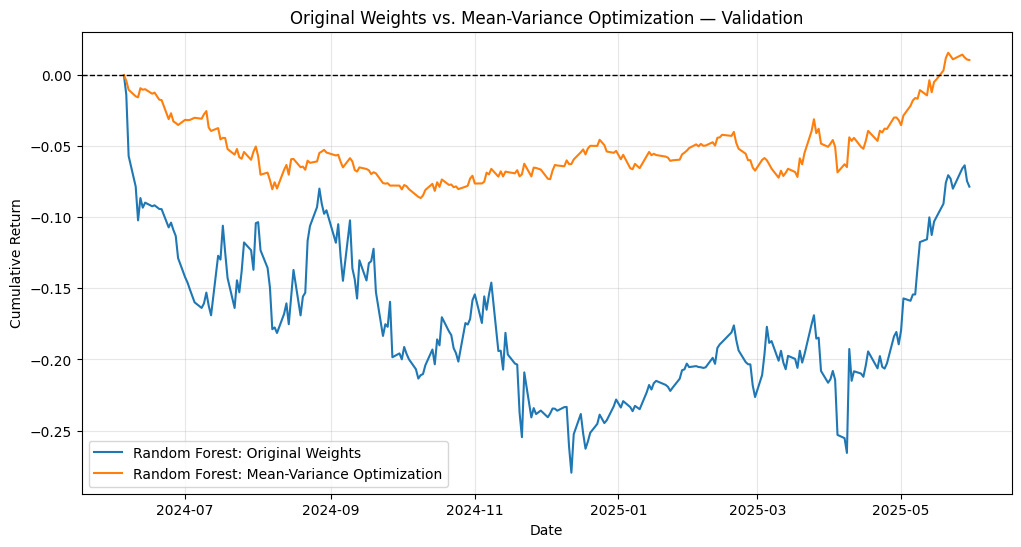

In [162]:
## Plot original and optimized portfolios

original_validation_curve = prepare_portfolio_curve(selected_original_portfolio, VALIDATION_START, VALIDATION_END)
optimized_validation_curve = prepare_portfolio_curve(optimized_validation_portfolio, VALIDATION_START, VALIDATION_END)

plt.figure(figsize=(12, 6))
plt.plot(original_validation_curve['ts_event'], original_validation_curve['cumulative_return'], label=f'{best_model_name}: Original Weights')
plt.plot(optimized_validation_curve['ts_event'], optimized_validation_curve['cumulative_return'], label=f'{best_model_name}: Mean-Variance Optimization')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Original Weights vs. Mean-Variance Optimization — Validation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Part 9 — Risk Preference Selection and Final Testing

## Objective

Complete the portfolio optimization framework, select the preferred risk level, and evaluate the final strategy on the Test set.

## Steps

1. Test several risk-aversion parameters using the Validation set.

2. Compare their portfolio returns, volatility, Sharpe ratios, and maximum drawdowns.

3. Select the preferred risk-aversion parameter based only on Validation performance.

4. Fix the selected model, covariance matrix, optimization constraints, and risk preference.

5. Apply the complete optimization framework to the Test set.

6. Report the final out-of-sample portfolio performance and verify that all portfolio constraints are satisfied.

In [163]:
# Week 9: Risk-preference selection and Test evaluation

def build_optimized_weight_table(prediction_matrix, covariance_matrix, rebalance_dates, risk_aversion, target_gross_exposure=2.0, maximum_absolute_weight=0.20):
    common_tickers = prediction_matrix.columns.intersection(covariance_matrix.columns)
    aligned_predictions = prediction_matrix[common_tickers]
    aligned_covariance = covariance_matrix.loc[common_tickers, common_tickers]

    optimized_weight_list = []

    for rebalance_date in rebalance_dates:
        expected_return_vector = aligned_predictions.loc[rebalance_date]

        weights = optimize_portfolio(
            expected_returns=expected_return_vector,
            covariance_matrix=aligned_covariance,
            risk_aversion=risk_aversion,
            target_gross_exposure=target_gross_exposure,
            maximum_absolute_weight=maximum_absolute_weight
        )

        weights.name = rebalance_date
        optimized_weight_list.append(weights)

    weight_table = pd.DataFrame(optimized_weight_list)
    weight_table.index.name = 'ts_event'

    return weight_table

In [164]:
def calculate_period_metrics(portfolio_summary, start_date, end_date, strategy_name):
    curve = prepare_portfolio_curve(portfolio_summary, start_date, end_date)
    curve['daily_return'] = (1 + curve['cumulative_return']).pct_change(fill_method=None)

    daily_return = curve['daily_return'].dropna()
    total_return = curve['cumulative_return'].iloc[-1]
    annualized_volatility = daily_return.std() * np.sqrt(252)
    sharpe_ratio = daily_return.mean() / daily_return.std() * np.sqrt(252) if daily_return.std() > 0 else np.nan

    wealth_index = 1 + curve['cumulative_return']
    drawdown = wealth_index / wealth_index.cummax() - 1

    return {
        'Strategy': strategy_name,
        'Total Return': total_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe': sharpe_ratio,
        'Maximum Drawdown': drawdown.min()
    }

In [165]:
## Test different risk preferences using Validation only

RISK_AVERSION_CANDIDATES = [1, 5, 10, 20, 50]

risk_preference_results = []
risk_preference_weights = {}
risk_preference_portfolios = {}

for risk_aversion in RISK_AVERSION_CANDIDATES:
    weights = build_optimized_weight_table(
        prediction_matrix=selected_validation_matrix,
        covariance_matrix=optimization_covariance_matrix,
        rebalance_dates=optimization_rebalance_dates,
        risk_aversion=risk_aversion,
        target_gross_exposure=TARGET_GROSS_EXPOSURE,
        maximum_absolute_weight=0.20
    )

    _, portfolio = multi_asset_backtester(
        data=data_common,
        weights=weights,
        capital=CAPITAL,
        delay=DELAY
    )

    metrics = calculate_period_metrics(
        portfolio_summary=portfolio,
        start_date=VALIDATION_START,
        end_date=VALIDATION_END,
        strategy_name=f'Risk Aversion = {risk_aversion}'
    )

    metrics['Risk Aversion'] = risk_aversion
    metrics['Average Gross Exposure'] = weights.abs().sum(axis=1).mean()
    metrics['Maximum Gross Exposure'] = weights.abs().sum(axis=1).max()

    risk_preference_results.append(metrics)
    risk_preference_weights[risk_aversion] = weights
    risk_preference_portfolios[risk_aversion] = portfolio

risk_preference_results = pd.DataFrame(risk_preference_results)

display(
    risk_preference_results.sort_values('Risk Aversion').style.format({
        'Total Return': '{:.2%}',
        'Annualized Volatility': '{:.2%}',
        'Sharpe': '{:.4f}',
        'Maximum Drawdown': '{:.2%}',
        'Average Gross Exposure': '{:.4f}',
        'Maximum Gross Exposure': '{:.4f}'
    })
)

,Strategy,Total Return,Annualized Volatility,Sharpe,Maximum Drawdown,Risk Aversion,Average Gross Exposure,Maximum Gross Exposure
0,Risk Aversion = 1,-5.23%,16.72%,-0.2460,-18.02%,1,2.0000,2.0000
1,Risk Aversion = 5,-2.29%,11.07%,-0.1587,-12.45%,5,2.0000,2.0000
2,Risk Aversion = 10,1.06%,8.17%,0.1730,-8.65%,10,2.0000,2.0000
3,Risk Aversion = 20,3.31%,6.19%,0.5694,-5.10%,20,2.0000,2.0000
4,Risk Aversion = 50,2.70%,4.21%,0.6681,-2.77%,50,1.9928,2.0000


In [166]:
## Select risk preference using Validation Sharpe only

risk_preference_ranking = (
    risk_preference_results
    .sort_values(
        ['Sharpe', 'Maximum Drawdown'],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

best_risk_aversion = risk_preference_ranking.loc[0, 'Risk Aversion']

print('Selected prediction model:', best_model_name)
print('Best risk aversion selected by Validation Sharpe:', best_risk_aversion)

display(
    risk_preference_ranking.style.format({
        'Total Return': '{:.2%}',
        'Annualized Volatility': '{:.2%}',
        'Sharpe': '{:.4f}',
        'Maximum Drawdown': '{:.2%}',
        'Average Gross Exposure': '{:.4f}',
        'Maximum Gross Exposure': '{:.4f}'
    })
)

Selected prediction model: Random Forest
Best risk aversion selected by Validation Sharpe: 50


,Strategy,Total Return,Annualized Volatility,Sharpe,Maximum Drawdown,Risk Aversion,Average Gross Exposure,Maximum Gross Exposure
0,Risk Aversion = 50,2.70%,4.21%,0.6681,-2.77%,50,1.9928,2.0000
1,Risk Aversion = 20,3.31%,6.19%,0.5694,-5.10%,20,2.0000,2.0000
2,Risk Aversion = 10,1.06%,8.17%,0.1730,-8.65%,10,2.0000,2.0000
3,Risk Aversion = 5,-2.29%,11.07%,-0.1587,-12.45%,5,2.0000,2.0000
4,Risk Aversion = 1,-5.23%,16.72%,-0.2460,-18.02%,1,2.0000,2.0000


In [167]:
## Prepare selected-model predictions for Test

selected_test_prediction = test_predictions[best_model_name]

selected_test_matrix = predictions_to_matrix(
    processed_dataset=test_processed,
    predictions=selected_test_prediction
)

test_tickers = selected_test_matrix.columns.intersection(optimization_covariance_matrix.columns)
selected_test_matrix = selected_test_matrix[test_tickers]
test_covariance_matrix = optimization_covariance_matrix.loc[test_tickers, test_tickers]

test_valid_dates = selected_test_matrix.dropna(how='any').index
test_rebalance_dates = test_valid_dates[::HOLDING_PERIOD]

print('Number of Test rebalance dates:', len(test_rebalance_dates))
print('Test covariance matrix shape:', test_covariance_matrix.shape)

Number of Test rebalance dates: 50
Test covariance matrix shape: (37, 37)


In [168]:
## Apply the selected risk preference to Test

optimized_test_weights = build_optimized_weight_table(
    prediction_matrix=selected_test_matrix,
    covariance_matrix=test_covariance_matrix,
    rebalance_dates=test_rebalance_dates,
    risk_aversion=best_risk_aversion,
    target_gross_exposure=TARGET_GROSS_EXPOSURE,
    maximum_absolute_weight=0.20
)

optimized_test_detail, optimized_test_portfolio = multi_asset_backtester(
    data=data_common,
    weights=optimized_test_weights,
    capital=CAPITAL,
    delay=DELAY
)

print('Optimized Test weight table shape:', optimized_test_weights.shape)
display(optimized_test_weights.head())

Optimized Test weight table shape: (50, 37)


ticker,AGG,DBA,DBC,DIA,EEM,EFA,EWJ,FXI,GDX,GLD,...,XLC,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
ts_event,,,,,,,,,,,,,,,,,,,,,
2025-06-02 00:00:00+00:00,-3.450690e-02,-0.014045,-0.058204,-1.818234e-01,-0.045020,5.193202e-02,-0.001768,0.005891,0.022365,0.152686,...,0.026144,-1.495875e-02,7.363154e-02,0.2,3.879575e-18,1.116589e-17,-0.051697,0.038022,0.039611,-3.418145e-18
2025-06-09 00:00:00+00:00,1.127211e-18,0.002639,-0.001982,-7.482129e-02,-0.041823,6.648494e-02,-0.003957,0.001902,0.121723,-0.113341,...,-0.011041,-1.688733e-02,6.487323e-02,0.2,-7.294956e-02,-1.447232e-02,-0.057243,0.018780,-0.053945,-7.542442e-02
2025-06-16 00:00:00+00:00,1.328255e-03,-0.023548,-0.015101,-1.251434e-01,0.010294,1.645699e-01,-0.035298,-0.017243,-0.043821,0.173981,...,0.023529,1.365789e-18,-8.225809e-18,0.2,1.804205e-17,1.863629e-02,-0.014261,0.014751,0.045554,-2.132256e-02
2025-06-24 00:00:00+00:00,1.726351e-01,0.004823,-0.015663,-1.934633e-01,-0.035241,-1.516156e-01,-0.008775,0.020960,0.085726,0.003959,...,0.008027,-4.002878e-03,1.069696e-01,0.2,6.865463e-02,-1.343417e-02,-0.045257,-0.008097,0.045121,-1.811811e-02
2025-07-01 00:00:00+00:00,2.016811e-18,-0.035951,0.016029,-1.514330e-17,0.066157,-4.378045e-18,-0.006976,-0.025917,0.002607,0.030492,...,-0.004755,-2.984813e-02,5.291968e-02,0.2,-2.000000e-01,-6.714953e-02,-0.002605,0.015918,-0.036621,-6.224743e-02


In [169]:
## Check Test portfolio constraints

test_weight_checks = pd.DataFrame({
    'Net Exposure': optimized_test_weights.sum(axis=1),
    'Gross Exposure': optimized_test_weights.abs().sum(axis=1),
    'Maximum Absolute Weight': optimized_test_weights.abs().max(axis=1)
})

display(
    test_weight_checks.describe().style.format({
        'Net Exposure': '{:.8f}',
        'Gross Exposure': '{:.6f}',
        'Maximum Absolute Weight': '{:.6f}'
    })
)

,Net Exposure,Gross Exposure,Maximum Absolute Weight
count,50.00000000,50.000000,50.000000
mean,-0.00000000,2.000000,0.199966
std,0.00000000,0.000000,0.000239
min,-0.00000000,2.000000,0.198311
25%,-0.00000000,2.000000,0.200000
50%,-0.00000000,2.000000,0.200000
75%,0.00000000,2.000000,0.200000
max,0.00000000,2.000000,0.200000


In [170]:
## Final out-of-sample Test performance

final_optimization_test_result = pd.DataFrame([
    calculate_period_metrics(
        portfolio_summary=optimized_test_portfolio,
        start_date=TEST_START,
        end_date=TEST_END,
        strategy_name=f'{best_model_name}, Risk Aversion = {best_risk_aversion}'
    )
])

final_optimization_test_result['Average Gross Exposure'] = optimized_test_weights.abs().sum(axis=1).mean()
final_optimization_test_result['Maximum Gross Exposure'] = optimized_test_weights.abs().sum(axis=1).max()

display(
    final_optimization_test_result.style.format({
        'Total Return': '{:.2%}',
        'Annualized Volatility': '{:.2%}',
        'Sharpe': '{:.4f}',
        'Maximum Drawdown': '{:.2%}',
        'Average Gross Exposure': '{:.4f}',
        'Maximum Gross Exposure': '{:.4f}'
    })
)

,Strategy,Total Return,Annualized Volatility,Sharpe,Maximum Drawdown,Average Gross Exposure,Maximum Gross Exposure
0,"Random Forest, Risk Aversion = 50",3.52%,4.85%,0.7521,-4.60%,2.0000,2.0000


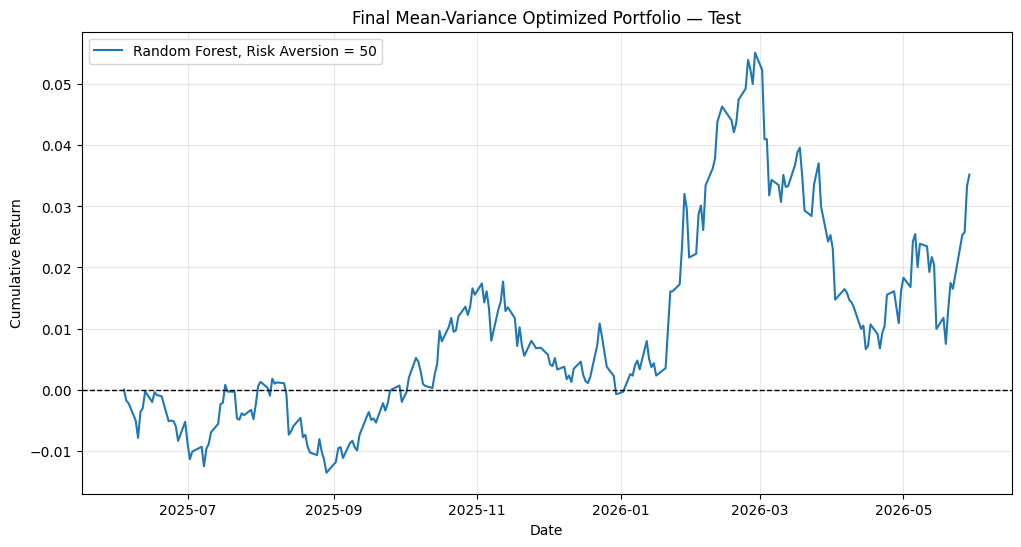

In [171]:
## Plot final Test cumulative return

optimized_test_curve = prepare_portfolio_curve(
    portfolio_summary=optimized_test_portfolio,
    start_date=TEST_START,
    end_date=TEST_END
)

plt.figure(figsize=(12, 6))
plt.plot(
    optimized_test_curve['ts_event'],
    optimized_test_curve['cumulative_return'],
    label=f'{best_model_name}, Risk Aversion = {best_risk_aversion}'
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Final Mean-Variance Optimized Portfolio — Test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()